# Jakarta Flood Risk Spatial Analysis
## A Multi-Criteria Spatial Data Science Approach

**Course:** Spatial Data Science  

---

## Overview

This notebook presents a comprehensive spatial analysis of flood vulnerability across Jakarta's administrative sub-districts (*kecamatan*). Using a Multi-Criteria Evaluation (MCE) framework, four geospatial indicators, elevation, flood hazard index, historical flood incidents, and river proximity are integrated into a weighted composite risk score. Spatial autocorrelation methods (Global Moran's I, LISA, Getis-Ord Gi*), spatial regression (OLS and ML Spatial Lag), and Kernel Density Estimation (KDE) are applied to reveal the spatial structure of flood hazard. The study concludes with evidence-based policy recommendations for drainage investment priorities and emergency shelter placement.

---


## 1. Library Imports

All required libraries are imported here. The project relies on standard geospatial Python libraries for raster processing (`rasterio`, `rasterstats`), vector analysis (`geopandas`), spatial statistics (`libpysal`, `esda`, `spreg`), and visualization (`matplotlib`).


In [1]:
# Standard scientific libraries
import os
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from shapely.ops import unary_union, nearest_points

# Geospatial libraries
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling as WarpResampling
from shapely.geometry import mapping
import rasterstats
import osmnx as ox

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# Spatial statistics
import libpysal
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local, Moran_Local_BV
from esda.getisord import G_Local
from splot.esda import plot_local_autocorrelation
import spreg
import copy
import jenkspy

print("All libraries imported successfully.")


d:\Desktop\spatial_data\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.


## 2. Project Path Configuration

All file paths are defined here relative to this notebook's location. The project folder must be structured as shown below. Place this notebook and the `data/` folder in the same directory and all paths will resolve automatically — **no manual edits are required**.

```
project_folder/
│
├── jakarta_flood_analysis.ipynb   ← This notebook
│
└── data/
    ├── jakarta_districts.geojson
    ├── jakarta_elevation_merged.tif
    ├── pop.tif
    ├── flood_hazard_2023_kecamatan.csv
    ├── flood_multiyear_kecamatan.csv
    ├── district_river_distance.csv
    ├── distance_to_rivers.npy
    └── jakarta_drainage_network.geojson
```


In [2]:
# Path Configuration 
# All paths are defined relative to this notebook's directory.
# As long as the 'data/' subfolder exists alongside this notebook, no changes are needed.

BASE_DIR  = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR  = os.path.join(BASE_DIR, "data")

# Input files
DISTRICTS_PATH     = os.path.join(DATA_DIR, "jakarta_districts.geojson")
ELEVATION_PATH     = os.path.join(DATA_DIR, "jakarta_elevation_merged.tif")
POPULATION_PATH    = os.path.join(DATA_DIR, "pop.tif")
HAZARD_PATH        = os.path.join(DATA_DIR, "flood_hazard_2023_kecamatan.csv")
MULTIYEAR_PATH     = os.path.join(DATA_DIR, "flood_multiyear_kecamatan.csv")
RIVER_DIST_PATH    = os.path.join(DATA_DIR, "district_river_distance.csv")
RIVER_NPY_PATH     = os.path.join(DATA_DIR, "distance_to_rivers.npy")
DRAINAGE_PATH      = os.path.join(DATA_DIR, "jakarta_drainage_network.geojson")

# Output files (saved alongside the notebook)
OUT_GETIS       = os.path.join(BASE_DIR, "getis_ord_map.png")
OUT_KDE         = os.path.join(BASE_DIR, "kde_flood_incidents.png")
OUT_DRAINAGE    = os.path.join(BASE_DIR, "drainage_recommendation.png")
OUT_SHELTER     = os.path.join(BASE_DIR, "shelter_recommendation.png")
OUT_SHELTER_PTS = os.path.join(BASE_DIR, "shelter_points.png")
OUT_LISA        = os.path.join(BASE_DIR, "lisa_clusters.png")

print("Path configuration complete.")
print(f"Base directory : {BASE_DIR}")
print(f"Data directory : {DATA_DIR}")


Path configuration complete.
Base directory : d:\Desktop\spatial_data\BSCS23095_UFPEAJ_FMS
Data directory : d:\Desktop\spatial_data\BSCS23095_UFPEAJ_FMS\data


---
## 3. Data Loading & Boundary Extraction

This section loads all spatial and tabular datasets required for the analysis:

- **Administrative boundaries** — Jakarta's five kotamadya (city divisions) are retrieved from OpenStreetMap via `osmnx` and dissolved into a single mainland polygon (removing offshore islands).
- **District polygons** — Sub-district (*kecamatan*) boundaries from a GeoJSON file, filtered to remove non-residential/administrative-only entries.
- **Elevation raster** — A merged Digital Elevation Model (DEM) clipped to the Jakarta study area.
- **Population raster** — WorldPop-derived population density raster clipped to Jakarta.
- **Tabular flood data** — Flood hazard index, multi-year incident counts, and river distance tables for each kecamatan.
- **Drainage network** — Jakarta's drainage canal and channel GeoJSON.


In [3]:
# Load pre-processed district boundaries 
districts_clean  = gpd.read_file(DISTRICTS_PATH)
jakarta_mainland = districts_clean.dissolve() # Combine all districts into a single geometry for mainland extraction

# Keep only the largest polygon (mainland) — removes offshore islands
# I did this because the original shapefile includes small offshore islands that are not relevant to the analysis and can cause issues with plotting and spatial operations.
jakarta_mainland['geometry'] = jakarta_mainland.geometry.apply(
    lambda geom: max(geom.geoms, key=lambda g: g.area) if geom.geom_type == 'MultiPolygon' else geom
)

print('Districts loaded:', len(districts_clean), 'kecamatan')
print('Geometry type:', jakarta_mainland.geometry.geom_type.values)

Districts loaded: 60 kecamatan
Geometry type: <StringArray>
['Polygon']
Length: 1, dtype: str


In [4]:
# remove any entries that contain 'PLN' in the name, as these are not actual districts but likely related to the power company and can cause confusion in the analysis.
districts_clean = districts_clean[~districts_clean['name'].str.contains('PLN', case=False)].reset_index(drop=True)
print(f'Districts loaded: {len(districts_clean)} kecamatan (after removing PLN entries)')


Districts loaded: 59 kecamatan (after removing PLN entries)


In [5]:
# Step 3c: Load Elevation Raster 
with rasterio.open(ELEVATION_PATH) as src:
    jakarta_reproj = jakarta_mainland.to_crs(src.crs)
    jakarta_geom   = [mapping(geom) for geom in jakarta_reproj.geometry]
    clipped_elev, clipped_elev_transform = mask(src, jakarta_geom, crop=True)
    clipped_elev_meta = src.meta.copy()

clipped_elev_meta.update({
    'height':    clipped_elev.shape[1],
    'width':     clipped_elev.shape[2],
    'transform': clipped_elev_transform
})
clipped_elev_data = clipped_elev[0].astype(float)
clipped_elev_data[clipped_elev_data == -32767.0] = np.nan

print(f'Elevation raster clipped: {clipped_elev_data.shape}')


Elevation raster clipped: (1028, 1039)


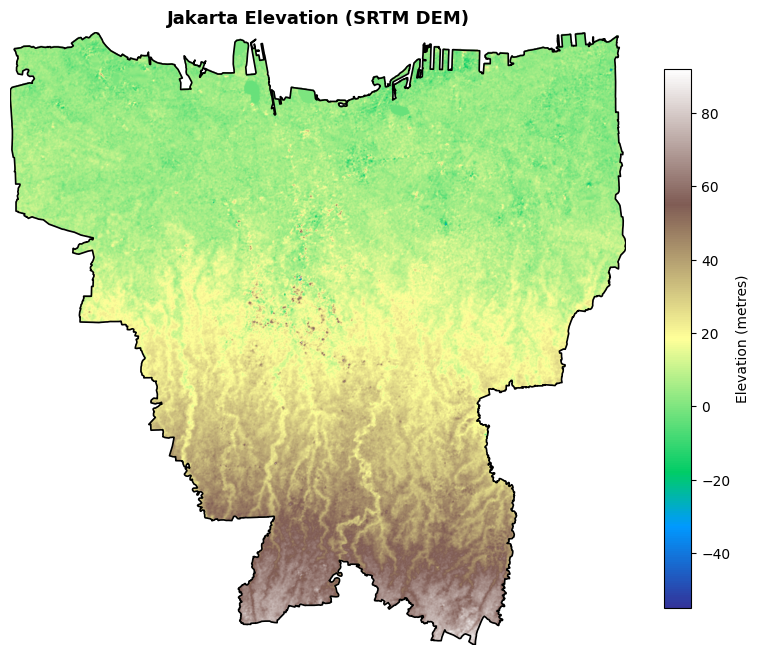

In [6]:
# Elevation Raster Visualisation 
fig, ax = plt.subplots(figsize=(8, 8))

img = ax.imshow(clipped_elev_data, cmap='terrain',
                extent=[clipped_elev_meta['transform'].c,
                        clipped_elev_meta['transform'].c + clipped_elev_meta['transform'].a * clipped_elev_data.shape[1],
                        clipped_elev_meta['transform'].f + clipped_elev_meta['transform'].e * clipped_elev_data.shape[0],
                        clipped_elev_meta['transform'].f])

plt.colorbar(img, ax=ax, label='Elevation (metres)', shrink=0.7)
jakarta_mainland.boundary.plot(ax=ax, color='black', linewidth=1.2)
ax.set_title('Jakarta Elevation (SRTM DEM)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Step 3d: Load Population Raster 
with rasterio.open(POPULATION_PATH) as src:
    jakarta_pop_reproj = jakarta_mainland.to_crs(src.crs)
    jakarta_pop_geom   = [mapping(jakarta_pop_reproj.geometry.iloc[0])]
    clipped_pop, clipped_pop_transform = mask(src, jakarta_pop_geom, crop=True)
    clipped_pop_meta = src.meta.copy()

clipped_pop_meta.update({
    'height':    clipped_pop.shape[1],
    'width':     clipped_pop.shape[2],
    'transform': clipped_pop_transform
})
clipped_pop_data = clipped_pop[0].astype(float)
clipped_pop_data[clipped_pop_data == -99999.0] = np.nan

print(f'Population raster clipped: {clipped_pop_data.shape}')


Population raster clipped: (343, 347)


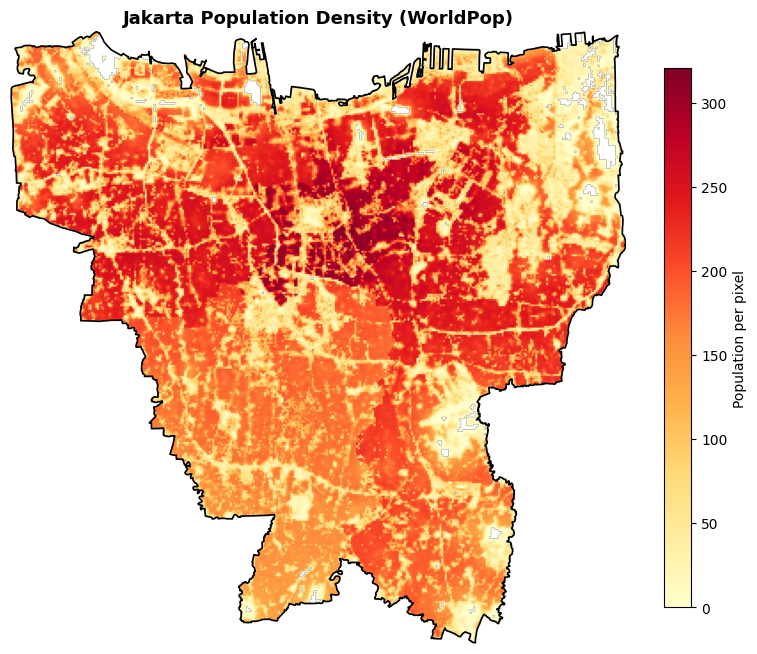

In [8]:
# Population Raster Visualisation 
fig, ax = plt.subplots(figsize=(8, 8))

img = ax.imshow(clipped_pop_data, cmap='YlOrRd',
                extent=[clipped_pop_meta['transform'].c,
                        clipped_pop_meta['transform'].c + clipped_pop_meta['transform'].a * clipped_pop_data.shape[1],
                        clipped_pop_meta['transform'].f + clipped_pop_meta['transform'].e * clipped_pop_data.shape[0],
                        clipped_pop_meta['transform'].f])

plt.colorbar(img, ax=ax, label='Population per pixel', shrink=0.7)
jakarta_mainland.boundary.plot(ax=ax, color='black', linewidth=1.2)
ax.set_title('Jakarta Population Density (WorldPop)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# Step 3e: Load tabular flood data and drainage network
hazard_kec       = pd.read_csv(HAZARD_PATH)
multi_year_stats = pd.read_csv(MULTIYEAR_PATH)
river_dist       = pd.read_csv(RIVER_DIST_PATH)
distance_meters  = np.load(RIVER_NPY_PATH)
drainage_gdf     = gpd.read_file(DRAINAGE_PATH)

print('all tabular and vector data loaded successfully.')

all tabular and vector data loaded successfully.


### Data Loading Summary

All datasets were successfully loaded. The elevation and population rasters are clipped to the Jakarta mainland study area, removing any data from the surrounding sea or adjacent provinces. Offshore-island polygons are removed from the administrative boundary to focus analysis on the contiguous urban area.


---
## 4. Data Preprocessing & Raster Alignment

Before computing district-level statistics, the elevation raster must be resampled to match the population raster's spatial resolution and extent. This ensures both grids are pixel-aligned, which is required for accurate zonal statistics. Tabular datasets are then standardized (title-cased and stripped of whitespace) and merged onto the district polygon layer.


In [10]:
# Step 4a: Resample elevation to match population raster resolution
elev_aligned = np.empty(clipped_pop_data.shape, dtype=np.float32)

with rasterio.open(ELEVATION_PATH) as elev_src:
    reproject(
        source=rasterio.band(elev_src, 1),
        destination=elev_aligned,
        src_transform=elev_src.transform,
        src_crs=elev_src.crs,
        dst_transform=clipped_pop_meta['transform'],
        dst_crs=elev_src.crs,
        resampling=WarpResampling.bilinear
    )

elev_aligned = elev_aligned.astype(float)
elev_aligned[elev_aligned == -32767.0] = np.nan
elev_aligned[np.isnan(clipped_pop_data)] = np.nan

print('Elevation resampled and aligned to population grid.')
print(f'Shape: {elev_aligned.shape}')


Elevation resampled and aligned to population grid.
Shape: (343, 347)


In [11]:
# Step 4b: compute zonal statistics per district 
district_stats = districts_clean[['name', 'geometry']].copy()

elev_stats = rasterstats.zonal_stats(
    district_stats, elev_aligned,
    affine=clipped_pop_meta['transform'], stats=['mean'], nodata=np.nan
)
pop_stats = rasterstats.zonal_stats(
    district_stats, clipped_pop_data,
    affine=clipped_pop_meta['transform'], stats=['sum'], nodata=np.nan
)

district_stats['mean_elevation'] = [s['mean'] for s in elev_stats]
district_stats['population']     = [s['sum']  for s in pop_stats]

print('Zonal statistics computed:')
print(district_stats[['name', 'mean_elevation', 'population']].head())


Zonal statistics computed:
                           name  mean_elevation     population
0                          Beji       68.218824    2603.860529
1                        Cinere       47.699141    5070.222416
2                     Jagakarsa       56.660035  360725.884296
3  Dinas Sosial Loka Bina Karya             NaN            NaN
4                  Pasar Minggu       37.017071  335083.294826


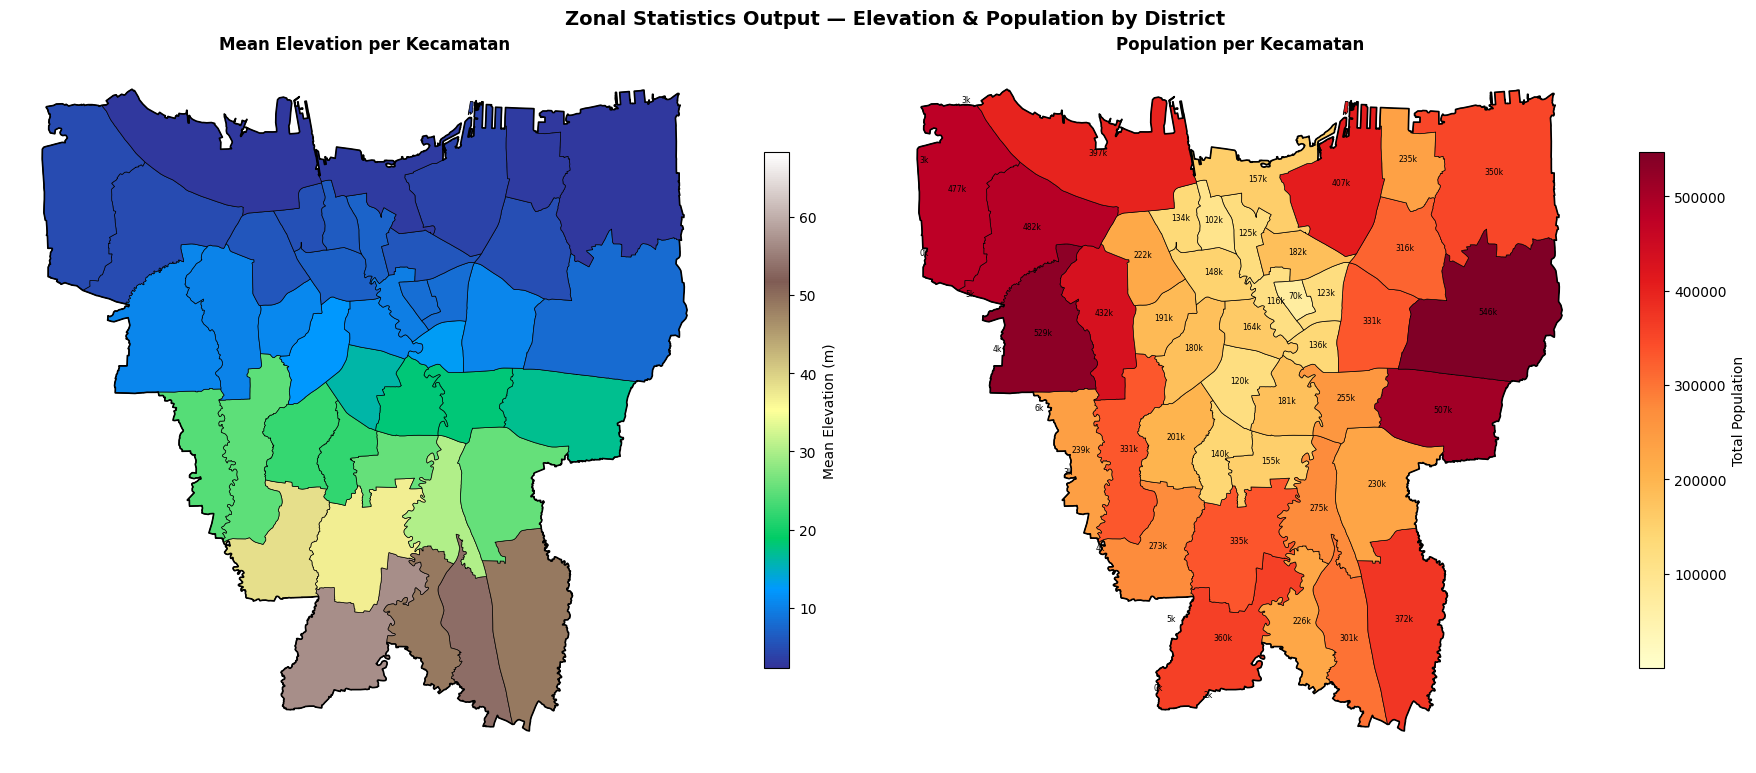

In [12]:
# elevation and population per district
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

district_stats.plot(column='mean_elevation', ax=axes[0], cmap='terrain',
                    legend=True, legend_kwds={'label': 'Mean Elevation (m)', 'shrink': 0.7},
                    edgecolor='black', linewidth=0.5)
jakarta_mainland.boundary.plot(ax=axes[0], color='black', linewidth=1.2)
axes[0].set_title('Mean Elevation per Kecamatan', fontsize=12, fontweight='bold')
axes[0].axis('off')

district_stats.plot(column='population', ax=axes[1], cmap='YlOrRd',
                    legend=True, legend_kwds={'label': 'Total Population', 'shrink': 0.7},
                    edgecolor='black', linewidth=0.5)
for idx, row in district_stats.iterrows():
    if pd.notna(row['population']):
        centroid = row.geometry.centroid
        axes[1].annotate(f"{int(row['population']/1000)}k",
                         xy=(centroid.x, centroid.y),
                         fontsize=5.5, ha='center', color='black')
jakarta_mainland.boundary.plot(ax=axes[1], color='black', linewidth=1.2)
axes[1].set_title('Population per Kecamatan', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Zonal Statistics Output — Elevation & Population by District',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Step 4c: standardise & merge tabular data
hazard_kec['kecamatan']         = hazard_kec['kecamatan'].str.title().str.strip()
multi_year_stats['subdistrict'] = multi_year_stats['subdistrict'].str.title().str.strip()
river_dist['name']              = river_dist['name'].str.title().str.strip()

district_stats = (district_stats
    .merge(hazard_kec[['kecamatan', 'hazard_index']],
           left_on='name', right_on='kecamatan', how='left')
    .drop(columns='kecamatan')
    .merge(multi_year_stats[['subdistrict', 'total_flood_incidents']],
           left_on='name', right_on='subdistrict', how='left')
    .drop(columns='subdistrict')
    .merge(river_dist[['name', 'mean_river_distance_m']], on='name', how='left')
)

# fill missing values with conservative defaults
district_stats['hazard_index']          = district_stats['hazard_index'].fillna(1.4)
district_stats['total_flood_incidents'] = district_stats['total_flood_incidents'].fillna(0)

# clip to Jakarta mainland boundary
district_stats = gpd.clip(district_stats, jakarta_mainland)

print('Data merged and clipped to Jakarta mainland.')
print(f'Columns: {list(district_stats.columns)}')


Data merged and clipped to Jakarta mainland.
Columns: ['name', 'geometry', 'mean_elevation', 'population', 'hazard_index', 'total_flood_incidents', 'mean_river_distance_m']


In [14]:
# Step 4d: remove non-Jakarta entries
outside_jakarta = [
    'Beji', 'Cinere', 'Limo', 'Larangan', 'Karang Tengah',
    'Ciputat Timur', 'Pondok Aren', 'Cipondoh', 'Batuceper',
    'Benda', 'Kosambi', 'Pt. Pln Area Cengkareng',
    'Sekretariat Tagana', 'Sekretariat Panwas Tambora',
    'Panitia Pemilihan Kecamatan', 'Koramil 08 Johar Baru',
    'Dinas Sosial Loka Bina Karya', 'Gedung Data Tomang'
]
district_stats = district_stats[~district_stats['name'].isin(outside_jakarta)].reset_index(drop=True)
district_stats = gpd.clip(district_stats, jakarta_mainland).reset_index(drop=True)

print(f'Final district count after cleaning: {len(district_stats)} kecamatan')


Final district count after cleaning: 42 kecamatan


### Data Loading & Preprocessing Summary

The pre-processed district boundaries, flood hazard index, multi-year incident records, river distances, and drainage network were loaded directly from files saved by the preprocessing notebook. The elevation and population rasters were clipped to the Jakarta mainland boundary and the elevation raster was resampled using bilinear interpolation to align pixel-for-pixel with the population grid. Zonal statistics (mean elevation, total population) were then extracted for each district polygon and merged with the tabular flood layers. Non-Jakarta administrative artefacts were removed and the resulting `district_stats` GeoDataFrame is the master analytical table used in all subsequent steps.

---
## 5. Multi-Criteria Evaluation (MCE) — Scoring & Composite Risk

A rule-based scoring system assigns each district a risk score (0–4) for each of five thematic indicators. Thresholds are set based on domain knowledge of Jakarta's flood hazard literature:

| Indicator | Weight | Rationale |
|---|---|---|
| Flood Hazard Index | 30% | Expert-derived composite hazard severity |
| Historical Flood Incidents | 45% | Empirical, directly observed impact measure |
| Mean Elevation | 15% | Primary topographic control on inundation |
| River Proximity | 10% | Proximity to fluvial overflow sources |

The weighted composite score (maximum = 4.0) is then classified into four risk tiers: **Low**, **Moderate**, **High**, and **Very High**.


In [15]:
# Step 5a Jenks Natural Breaks Scoring

import jenkspy
import numpy as np

# number of classes
N_CLASSES = 5   # gives scores 0–4

# computing jenks
elev_breaks = jenkspy.jenks_breaks(
    district_stats['mean_elevation'].dropna(),
    n_classes=N_CLASSES
)

hazard_breaks = jenkspy.jenks_breaks(
    district_stats['hazard_index'].dropna(),
    n_classes=N_CLASSES
)

incident_breaks = jenkspy.jenks_breaks(
    district_stats['total_flood_incidents'].dropna(),
    n_classes=N_CLASSES
)

river_breaks = jenkspy.jenks_breaks(
    district_stats['mean_river_distance_m'].dropna(),
    n_classes=N_CLASSES
)

print("Elevation breaks:", elev_breaks)
print("Hazard breaks:", hazard_breaks)
print("Incident breaks:", incident_breaks)
print("River distance breaks:", river_breaks)


# scoring func
def jenks_score(value, breaks, reverse=False):
   
    for i in range(1, len(breaks)):
        if value <= breaks[i]:
            score = i - 1
            break
    else:
        score = len(breaks) - 2

    if reverse:
        score = (len(breaks) - 2) - score

    return score


# Low elevation = high flood risk
def score_elevation(elev):
    return jenks_score(elev, elev_breaks, reverse=True)

# High hazard index = high flood risk
def score_hazard(idx):
    return jenks_score(idx, hazard_breaks, reverse=False)

# High incidents = high flood risk
def score_incidents(n):
    return jenks_score(n, incident_breaks, reverse=False)

# Small river distance = high flood risk
def score_river(dist):
    return jenks_score(dist, river_breaks, reverse=True)

print('Jenks-based scoring functions defined.')

Elevation breaks: [np.float64(2.884278433524068), np.float64(7.089247237637898), np.float64(16.01941370365152), np.float64(25.44308516826826), np.float64(38.522964340246816), np.float64(56.66003452879168)]
Hazard breaks: [np.float64(1.3999999999999997), np.float64(1.4), np.float64(1.5333333333333332), np.float64(1.6), np.float64(1.8), np.float64(2.3)]
Incident breaks: [np.float64(2.0), np.float64(17.0), np.float64(44.0), np.float64(69.0), np.float64(95.0), np.float64(139.0)]
River distance breaks: [np.float64(201.49703912813555), np.float64(492.9244871672827), np.float64(928.103679124004), np.float64(1991.7958220926628), np.float64(2592.657067915773), np.float64(3716.9087155877664)]
Jenks-based scoring functions defined.


In [16]:
# Step 5b: apply scoring to each district
district_stats['elev_score']     = district_stats['mean_elevation'].apply(score_elevation)
district_stats['hazard_score']   = district_stats['hazard_index'].apply(score_hazard)
district_stats['incident_score'] = district_stats['total_flood_incidents'].apply(score_incidents)
district_stats['river_score']    = district_stats['mean_river_distance_m'].apply(score_river)

print('Individual scores applied.')
print(district_stats[['name', 'elev_score', 'hazard_score', 'incident_score', 'river_score']].head(8))


Individual scores applied.
               name  elev_score  hazard_score  incident_score  river_score
0         Jagakarsa           0             0               1            3
1        Pasar Rebo           0             0               1            4
2      Pasar Minggu           1             0               3            3
3          Pancoran           2             2               2            3
4  Mampang Prapatan           2             3               1            4
5             Tebet           2             0               2            3
6         Setiabudi           3             0               0            4
7           Menteng           3             0               0            4


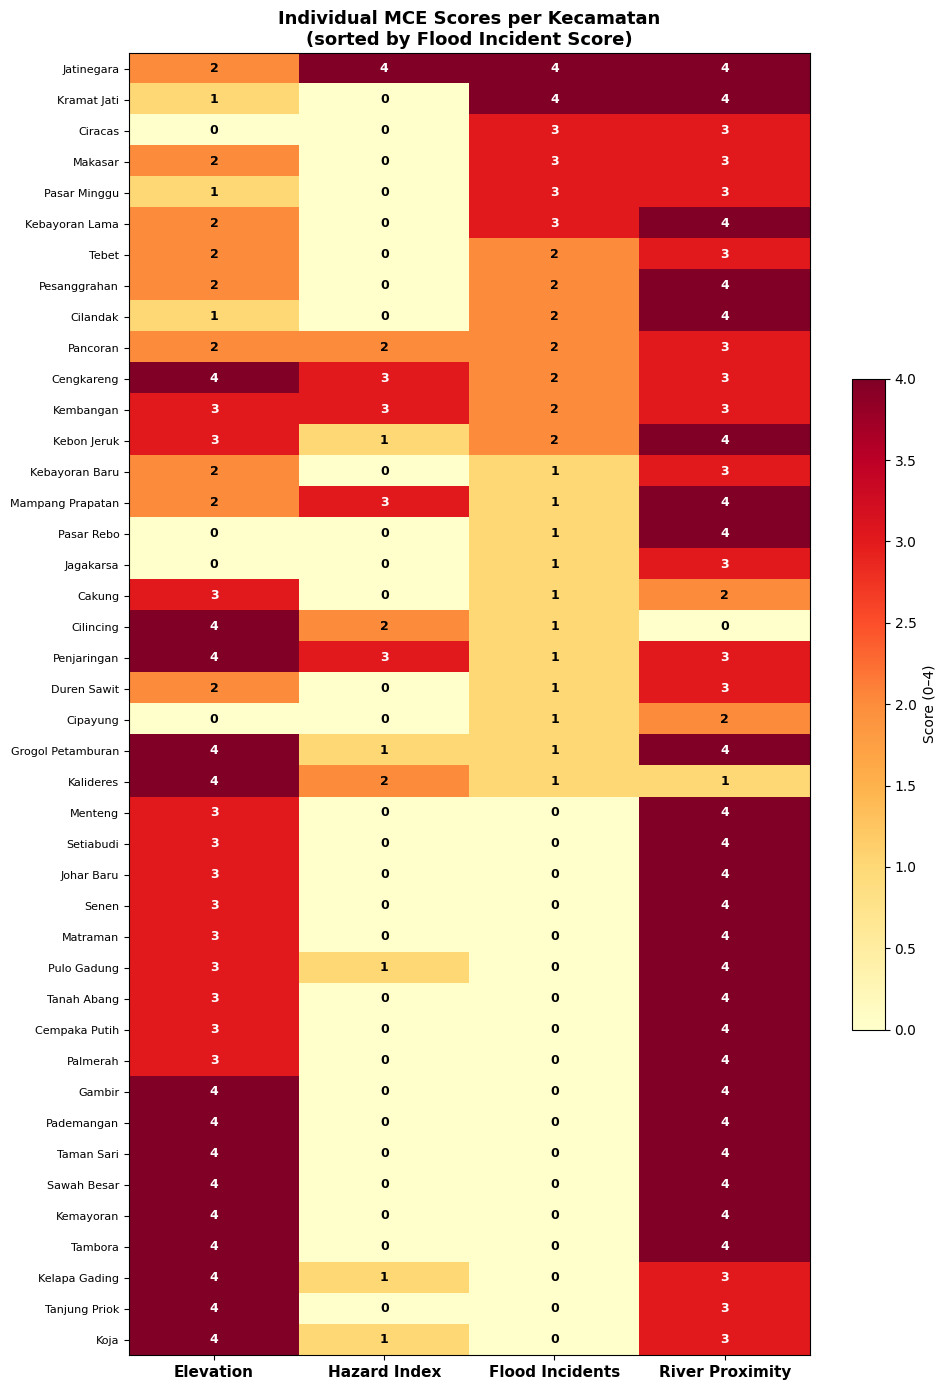

In [17]:
# individual score heatmap per district
score_cols = ['elev_score', 'hazard_score', 'incident_score', 'river_score']
score_labels = ['Elevation', 'Hazard Index', 'Flood Incidents', 'River Proximity']

score_matrix = district_stats.set_index('name')[score_cols].sort_values('incident_score', ascending=False)
score_matrix.columns = score_labels

fig, ax = plt.subplots(figsize=(10, 14))
im = ax.imshow(score_matrix.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=4)

ax.set_xticks(range(len(score_labels)))
ax.set_xticklabels(score_labels, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(score_matrix)))
ax.set_yticklabels(score_matrix.index, fontsize=8)

for i in range(len(score_matrix)):
    for j in range(len(score_labels)):
        ax.text(j, i, str(int(score_matrix.values[i, j])),
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='black' if score_matrix.values[i, j] < 3 else 'white')

plt.colorbar(im, ax=ax, label='Score (0–4)', shrink=0.5)
ax.set_title('Individual MCE Scores per Kecamatan\n(sorted by Flood Incident Score)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Step 5c: compute weighted composite score
district_stats['composite_score'] = (
    0.15 * district_stats['elev_score']     +
    0.30 * district_stats['hazard_score']   +
    0.45 * district_stats['incident_score'] +
    0.10 * district_stats['river_score']
)

print('Composite score computed.')
print(f'Score range: {district_stats["composite_score"].min():.2f}  {district_stats["composite_score"].max():.2f}')


Composite score computed.
Score range: 0.65  3.70


In [19]:
# Step 5d: classify risk tiers
def classify_risk(score):
    if score >= 2.1:   return 'Very High'
    elif score >= 1.6: return 'High'
    elif score >= 1.2: return 'Moderate'
    else:              return 'Low'

district_stats['risk_level'] = district_stats['composite_score'].apply(classify_risk)

risk_colors = {
    'Very High': '#b92b3c',
    'High':      '#d64e28',
    'Moderate':  '#f18648',
    'Low':       '#efbd6c'
}
district_stats['color'] = district_stats['risk_level'].map(risk_colors)

print('=== RISK LEVEL DISTRIBUTION ===')
print(district_stats['risk_level'].value_counts())
print(f'Total kecamatan: {len(district_stats)}')


=== RISK LEVEL DISTRIBUTION ===
risk_level
Low          22
High         11
Very High     5
Moderate      4
Name: count, dtype: int64
Total kecamatan: 42


In [20]:
# Step 5e: print full ranked score table
print('=== COMPOSITE RISK SCORE — ALL DISTRICTS ===')
print(district_stats[['name', 'mean_elevation', 'hazard_index', 'total_flood_incidents',
                        'elev_score', 'hazard_score', 'incident_score',
                        'river_score', 'composite_score', 'risk_level']]
      .sort_values('composite_score', ascending=False)
      .to_string())


=== COMPOSITE RISK SCORE — ALL DISTRICTS ===
                 name  mean_elevation  hazard_index  total_flood_incidents  elev_score  hazard_score  incident_score  river_score  composite_score risk_level
15         Jatinegara       18.150812      2.300000                  139.0           2             4               4            4             3.70  Very High
34         Cengkareng        4.768650      1.766667                   69.0           4             3               2            3             2.70  Very High
26          Kembangan       10.360541      1.680000                   54.0           3             3               2            3             2.55  Very High
12        Kramat Jati       30.373796      1.400000                  132.0           1             0               4            4             2.35  Very High
37        Penjaringan        3.021092      1.800000                   37.0           4             3               1            3             2.25  Very High
3      

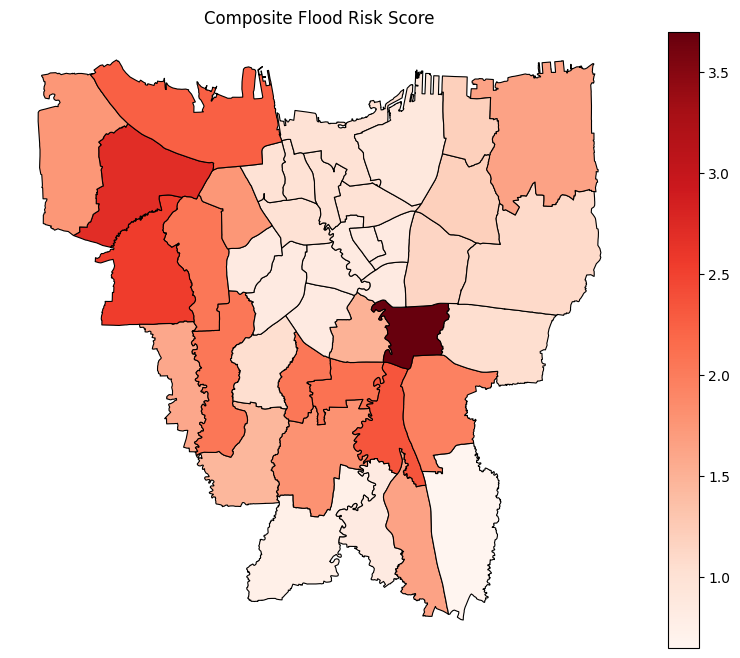

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))

district_stats.plot(
    column='composite_score',
    cmap='Reds',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    ax=ax
)

plt.title('Composite Flood Risk Score')
plt.axis('off')
plt.show()

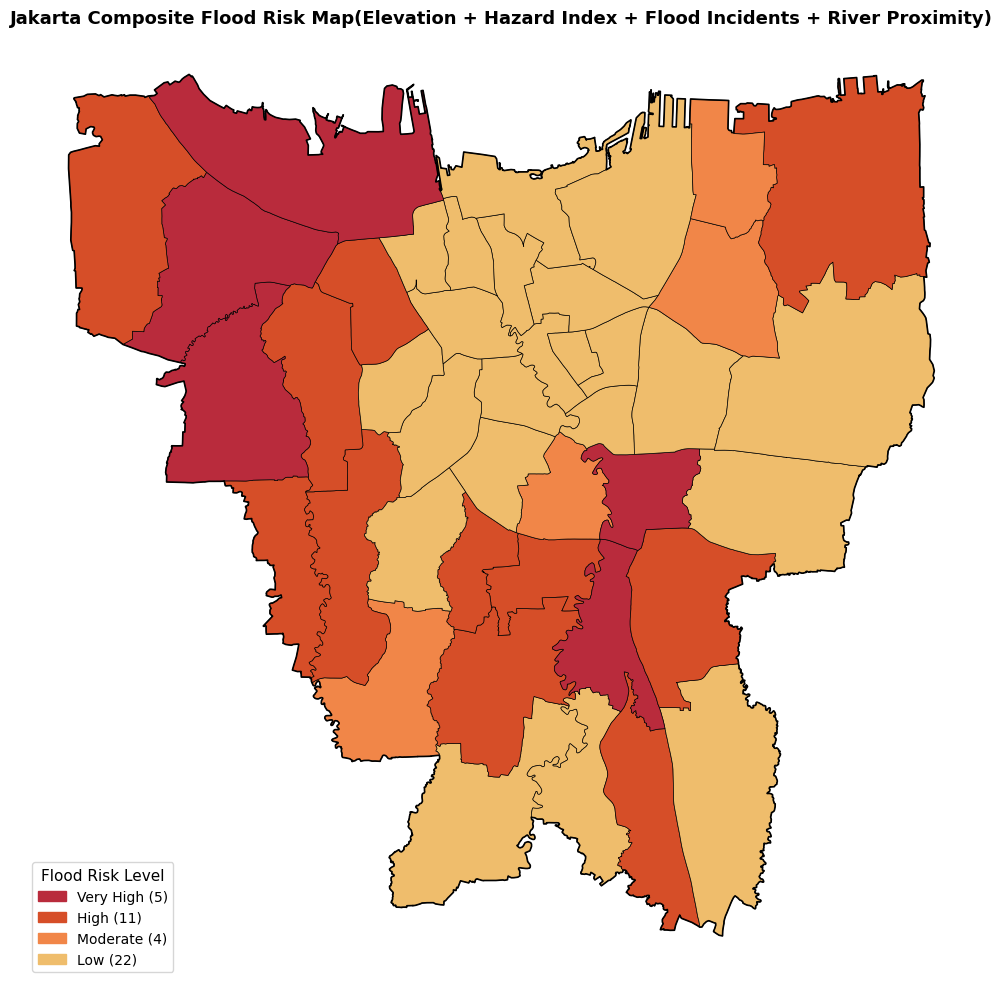

In [22]:
# Step 5f: visualise composite flood risk map
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

district_stats['color'] = district_stats['risk_level'].map(risk_colors).fillna('#cccccc')

risk_order = ['Very High', 'High', 'Moderate', 'Low']
district_stats.plot(color=district_stats['color'], ax=ax, edgecolor='black', linewidth=0.5)
jakarta_mainland.boundary.plot(ax=ax, color='black', linewidth=1.2)

legend_patches = [
    mpatches.Patch(color=risk_colors[r],
                   label=f'{r} ({len(district_stats[district_stats["risk_level"] == r])})')
    for r in risk_order if r in district_stats['risk_level'].values
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=10,
          title='Flood Risk Level', title_fontsize=11)
ax.set_title('Jakarta Composite Flood Risk Map(Elevation + Hazard Index + Flood Incidents + River Proximity)',
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.show()


### MCE Results

The composite scoring reveals a clear spatial gradient in flood vulnerability across Jakarta. Districts in **North and East Jakarta** — characterised by low elevation, high hazard indices, and extensive historical flooding — dominate the Very High and High risk tiers. **South Jakarta** districts, which sit on higher ground further from river channels, consistently score as Low or Moderate risk. This geographic pattern closely aligns with Jakarta's known flood history and provides the empirical foundation for all subsequent spatial analyses.


---
## 6. Spatial Weights Matrix Construction

A **Queen contiguity weights matrix** is constructed from the district polygons. Under Queen contiguity, two districts are considered neighbours if they share any boundary point (including corners). The matrix is row-standardised so that each district's neighbours' values are averaged rather than summed — this is the standard form required for Moran's I and LISA calculations.


In [23]:
# Step 6: build queen contiguity spatial weights matrix
w = Queen.from_dataframe(district_stats, use_index=False)
w.transform = 'r'   # Row-standardise

print(f'Weights matrix built.')

Weights matrix built.


### Weights Matrix Summary

The Queen contiguity matrix captures the neighbourhood structure of Jakarta's 42 kecamatan. An average of ~5 neighbours per district reflects the city's irregular but well-connected polygon topology. Row-standardisation ensures that the spatial lag of any variable represents the **mean** value across a district's neighbours, making Moran's I directly interpretable as a correlation coefficient.


---
## 7. Global Spatial Autocorrelation — Moran's I

**Global Moran's I** measures whether the overall spatial distribution of flood risk is clustered, dispersed, or random. A positive and significant Moran's I indicates that similar values (high-risk districts next to high-risk districts, or low-risk next to low-risk) occur more often than would be expected by chance.

- **I > 0**: Positive spatial autocorrelation (clustering)  
- **I < 0**: Negative spatial autocorrelation (dispersion)  
- **p < 0.05**: The pattern is statistically significant


In [24]:
# Step 7a: run global moran's I
moran = Moran(district_stats['composite_score'], w)

print('GLOBAL MORANS I:')
print(f'Morans I statistic: {moran.I:.4f}')
print(f'Expected I: {moran.EI:.4f}')
print(f'P-value: {moran.p_sim:.4f}')
print(f'Z-score: {moran.z_sim:.4f}')
print()
if moran.p_sim < 0.05:
    if moran.I > 0:
        print('Result: SIGNIFICANT POSITIVE SPATIAL AUTOCORRELATION')
        print('meaning: High risk districts tend to cluster near other high risk districts')
    else:
        print('Result: SIGNIFICANT NEGATIVE SPATIAL AUTOCORRELATION')
        print('meaning: High risk districts tend to be surrounded by low risk districts')
else:
    print('Result: NO SIGNIFICANT SPATIAL AUTOCORRELATION')
    print('meaning: Flood risk is randomly distributed across Jakarta')


GLOBAL MORANS I:
Morans I statistic: 0.3106
Expected I: -0.0244
P-value: 0.0030
Z-score: 3.7352

Result: SIGNIFICANT POSITIVE SPATIAL AUTOCORRELATION
meaning: High risk districts tend to cluster near other high risk districts


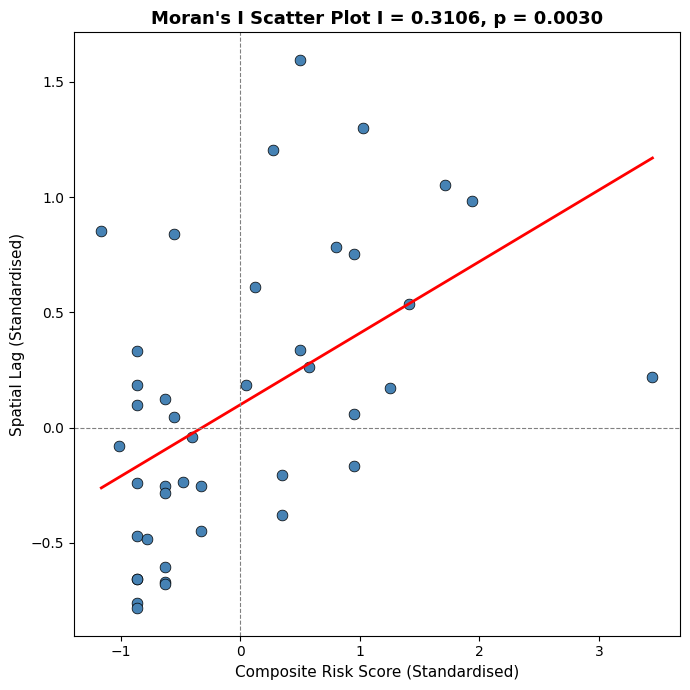

In [25]:
# Step 7b: moran's I scatter plot
z = (district_stats['composite_score'] - district_stats['composite_score'].mean()) / district_stats['composite_score'].std()
w_copy = copy.deepcopy(w)
lag_z = libpysal.weights.lag_spatial(w_copy, z)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(z, lag_z, color='steelblue', edgecolor='black', linewidth=0.5, s=60)

# regression line — slope equals Moran's I
m, b    = np.polyfit(z, lag_z, 1)
x_line  = np.linspace(z.min(), z.max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2)

# quadrant reference lines
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')

ax.set_xlabel('Composite Risk Score (Standardised)', fontsize=11)
ax.set_ylabel('Spatial Lag (Standardised)', fontsize=11)
ax.set_title(f"Moran's I Scatter Plot I = {moran.I:.4f}, p = {moran.p_sim:.4f}",fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Global Moran's I Results

The Global Moran's I statistics confirms statistically significant positive spatial autocorrelation in Jakarta's flood risk distribution. High-risk kecamatan are systematically located adjacent to other high-risk kecamatan, and low-risk districts similarly cluster together. The Moran scatter plot visually confirms this: the positive slope of the regression line demonstrates that knowing a district's own risk score is a meaningful predictor of its neighbours' risk scores. This non-random spatial structure justifies the application of local cluster detection methods in the next section.

---
## 8. Local Spatial Autocorrelation — LISA (Local Moran's I)

**Local Indicators of Spatial Association (LISA)** decompose the global statistic into district-level contributions, identifying where significant spatial clusters and outliers occur. Each district is classified into one of five categories based on its own value and the average value of its neighbours:

| Category | Meaning |
|---|---|
| **High-High** | High-risk district surrounded by high-risk neighbours — core hotspot |
| **Low-Low** | Low-risk district surrounded by low-risk neighbours — core coldspot |
| **Low-High** | Low-risk district surrounded by high-risk neighbours — spatial outlier |
| **High-Low** | High-risk district surrounded by low-risk neighbours — spatial outlier |
| **Not Significant** | No statistically significant local cluster (p ≥ 0.05) |

*Note: In `esda`'s quadrant coding, q=1=HH, q=2=LH, q=3=LL, q=4=HL.*


In [26]:
# Step 8a: run local Moran's I (LISA)
lisa = Moran_Local(district_stats['composite_score'], w)

print('=== LOCAL MORANS I (LISA) ===')
print(f'Significant locations (p<0.05): {(lisa.p_sim < 0.05).sum()}')
print(f'\nCluster types:')
print(f'High-High (hotspots):  {((lisa.q == 1) & (lisa.p_sim < 0.05)).sum()}')
print(f'Low-Low  (coldspots):  {((lisa.q == 3) & (lisa.p_sim < 0.05)).sum()}')
print(f'Low-High (outliers):   {((lisa.q == 2) & (lisa.p_sim < 0.05)).sum()}')
print(f'High-Low (outliers):   {((lisa.q == 4) & (lisa.p_sim < 0.05)).sum()}')


=== LOCAL MORANS I (LISA) ===
Significant locations (p<0.05): 14

Cluster types:
High-High (hotspots):  7
Low-Low  (coldspots):  7
Low-High (outliers):   0
High-Low (outliers):   0


In [27]:
# Step 8b: assign LISA cluster labels
def lisa_label(q, p):
    if p >= 0.05:  return 'Not Significant'
    elif q == 1:   return 'High-High'
    elif q == 3:   return 'Low-Low'
    elif q == 2:   return 'Low-High'
    elif q == 4:   return 'High-Low'

district_stats['lisa_cluster'] = [lisa_label(q, p) for q, p in zip(lisa.q, lisa.p_sim)]

print('LISA cluster distribution:')
print(district_stats['lisa_cluster'].value_counts())


LISA cluster distribution:
lisa_cluster
Not Significant    28
High-High           7
Low-Low             7
Name: count, dtype: int64


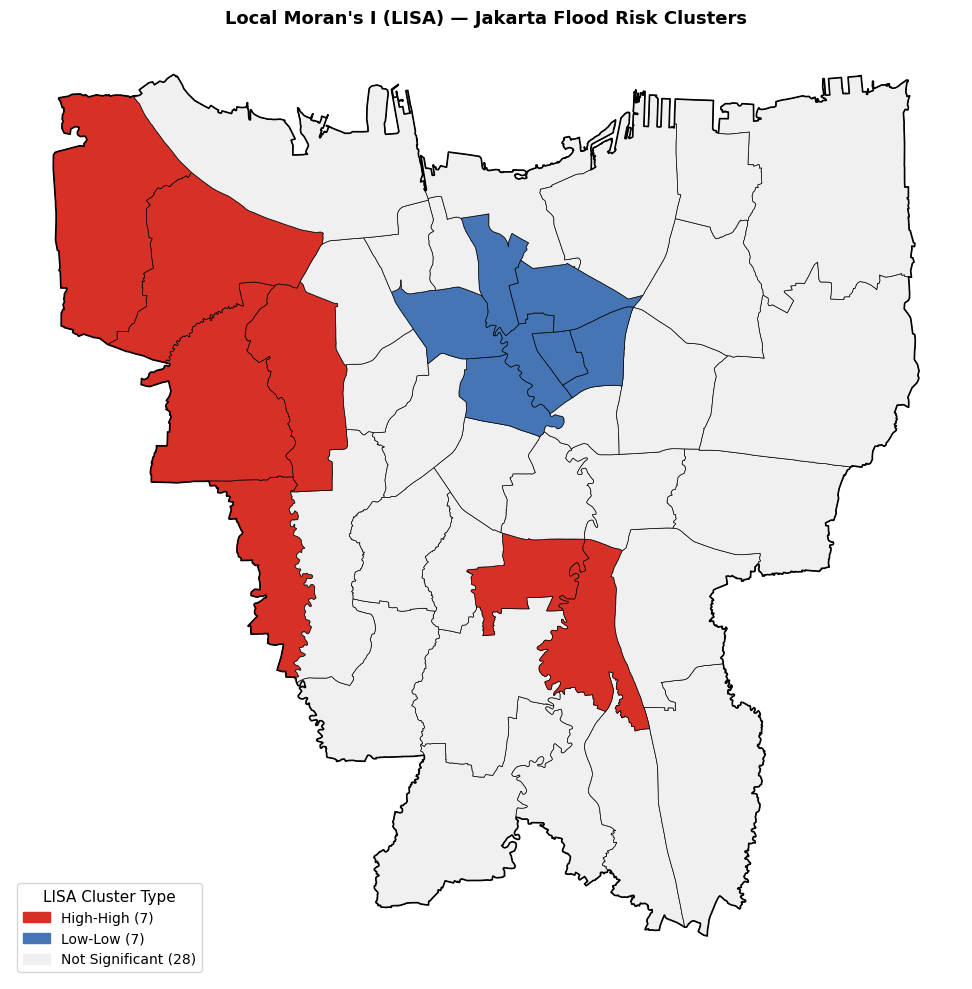

In [28]:
# Step 8c: LISA cluster map 
lisa_colors = {
    'High-High':       '#d73027',
    'Low-Low':         '#4575b4',
    'High-Low':        '#fdae61',
    'Low-High':        '#abd9e9',
    'Not Significant': '#f0f0f0'
}
district_stats['lisa_color'] = district_stats['lisa_cluster'].map(lisa_colors)

fig, ax = plt.subplots(figsize=(10, 10))
district_stats.plot(color=district_stats['lisa_color'], ax=ax, edgecolor='black', linewidth=0.5)
jakarta_mainland.boundary.plot(ax=ax, color='black', linewidth=1.2)

lisa_order = ['High-High', 'Low-Low', 'High-Low', 'Low-High', 'Not Significant']
legend_patches = [
    mpatches.Patch(color=lisa_colors[l],
                   label=f'{l} ({len(district_stats[district_stats["lisa_cluster"] == l])})')
    for l in lisa_order if l in district_stats['lisa_cluster'].values
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=10,
          title='LISA Cluster Type', title_fontsize=11)
ax.set_title("Local Moran's I (LISA) — Jakarta Flood Risk Clusters",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_LISA, dpi=150, bbox_inches='tight')
plt.show()


In [29]:
print("Elevation of Very High risk districts:")
print(district_stats[district_stats['risk_level'] == 'Very High'][['name', 'mean_elevation']])

print("\nElevation of LISA High-High clusters:")
print(district_stats[district_stats['lisa_cluster'] == 'High-High'][['name', 'mean_elevation']])

Elevation of Very High risk districts:
           name  mean_elevation
12  Kramat Jati       30.373796
15   Jatinegara       18.150812
26    Kembangan       10.360541
34   Cengkareng        4.768650
37  Penjaringan        3.021092

Elevation of LISA High-High clusters:
            name  mean_elevation
3       Pancoran       25.394744
12   Kramat Jati       30.373796
21  Pesanggrahan       24.407932
25   Kebon Jeruk       10.257270
26     Kembangan       10.360541
34    Cengkareng        4.768650
36     Kalideres        4.829709


### LISA Results

The LISA map shows statistically significant High–High clusters mainly in western Jakarta (around Cengkareng–Kalideres–Penjaringan) and another cluster in the south-central region, indicating concentrated flood risk where neighboring districts also exhibit high values.

Low–Low clusters are observed in central Jakarta, forming a relatively stable low-risk core surrounded by similarly low-risk districts.

Overall, the pattern shows clear spatial clustering of flood risk with two main hotspot regions and a central coldspot zone, confirming strong spatial dependence across districts.

---
## 9. Spatial Regression — Ordinary Least Squares (OLS) with Diagnostics

Before fitting a spatially-aware model, an OLS regression is run with spatial diagnostics. This serves as a baseline and formally tests whether ignoring spatial dependence introduces bias. The model regresses total flood incidents on mean elevation and mean river distance. Lagrange Multiplier tests detect whether a Spatial Lag or Spatial Error extension is needed.


In [30]:
# Step 13a: Calculate Drainage Density per District
drainage_gdf_proj = drainage_gdf.to_crs(epsg=3857)
districts_proj    = district_stats.to_crs(epsg=3857)
districts_proj['area_km2'] = districts_proj.geometry.area / 1e6

drainage_counts = []
for idx, district in districts_proj.iterrows():
    count = drainage_gdf_proj[drainage_gdf_proj.geometry.within(district.geometry)].shape[0]
    drainage_counts.append(count)

district_stats['drainage_count']   = drainage_counts
district_stats['area_km2']         = districts_proj['area_km2'].values
district_stats['drainage_density'] = district_stats['drainage_count'] / district_stats['area_km2']

print('Drainage density calculated.')
print(district_stats[['name', 'drainage_count', 'area_km2', 'drainage_density']]
      .sort_values('drainage_density', ascending=False).to_string())


Drainage density calculated.
                 name  drainage_count   area_km2  drainage_density
35            Tambora              20   5.533420          3.614401
24        Tanah Abang              37  10.238703          3.613739
28             Gambir              27   7.625057          3.540957
30          Kemayoran              16   7.295639          2.193091
32         Taman Sari              10   4.584528          2.181249
6           Setiabudi              15   9.084365          1.651189
22     Kebayoran Lama              31  19.619897          1.580029
38      Kelapa Gading              22  16.254355          1.353483
9          Johar Baru               3   2.426135          1.236535
17        Pulo Gadung              18  15.226448          1.182154
5               Tebet              11   9.519676          1.155501
13            Makasar              23  21.658622          1.061933
34         Cengkareng              27  26.161537          1.032049
12        Kramat Jati            

In [31]:
regression_data = district_stats[['total_flood_incidents','mean_elevation','mean_river_distance_m','drainage_density','geometry']].dropna()

print(f'Original rows: {len(district_stats)},  Rows after removing NaNs: {len(regression_data)}')

y = regression_data['total_flood_incidents'].values.reshape(-1, 1)

X = regression_data[
    ['mean_elevation',
     'mean_river_distance_m',
     'drainage_density']
].values

Original rows: 42,  Rows after removing NaNs: 42


In [32]:
# Step 9b: Run OLS with Spatial Diagnostics
ols = spreg.OLS(
    y, X, w=w,
    name_y='incidents',
    name_x=['elevation', 'river_dist', 'drainage_density'],
    spat_diag=True
)

print(ols.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   incidents                Number of Observations:          42
Mean dependent var  :     36.7857                Number of Variables   :           4
S.D. dependent var  :     34.2619                Degrees of Freedom    :          38
R-squared           :      0.2642
Adjusted R-squared  :      0.2061
Sum squared residual:     35412.2                F-statistic           :      4.5487
Sigma-square        :     931.899                Prob(F-statistic)     :    0.008073
S.E. of regression  :      30.527                Log likelihood        :    -201.075
Sigma-square ML     :     843.147                Akaike info criterion :     410.151
S.E of regression ML:     29.0370                Schwarz criterion     :     417.101

------------------------------------------------------------

### OLS Results & Interpretation

The OLS model indicates that elevation is a statistically significant predictor of flood incidents (p < 0.01), while river distance and drainage density are not statistically significant at the 5% level. The model explains a moderate proportion of variance (R² = 0.26), suggesting that local physical factors alone do not fully capture flood variability.

However, the Lagrange Multiplier (Lag) test is statistically significant, indicating the presence of spatial dependence in the dependent variable. This suggests that flood incidents are influenced by neighboring districts, violating the independence assumption of OLS. Therefore, a Spatial Lag model is more appropriate, as it accounts for these spatial spillover effects and reduces bias in coefficient estimation.

---
## 10. Spatial Regression — Maximum Likelihood Spatial Lag Model

The **ML Spatial Lag model** corrects the OLS violation by incorporating a spatially-lagged dependent variable ($W\_incidents$) — the weighted average of flood incidents in each district's neighbours — directly into the regression equation. This accounts for the neighbourhood spillover effect identified by the LM Lag diagnostic.


In [33]:
# Step 10: Run Spatial Lag Model (ML Lag) 
spatial_lag_model = spreg.ML_Lag(
    y, X, w=w,
    name_y='incidents',
    name_x=['elevation', 'river_dist','drainage_density']
)

print('=== SPATIAL LAG REGRESSION RESULTS ===')
print(spatial_lag_model.summary)


=== SPATIAL LAG REGRESSION RESULTS ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   incidents                Number of Observations:          42
Mean dependent var  :     36.7857                Number of Variables   :           5
S.D. dependent var  :     34.2619                Degrees of Freedom    :          37
Pseudo R-squared    :      0.4259
Spatial Pseudo R-squared:  0.3353
Log likelihood      :   -197.5009
Sigma-square ML     :    664.8792                Akaike info criterion :     405.002
S.E of regression   :     25.7853                Schwarz criterion     :     413.690

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------

### Spatial Lag Model Results & Interpretation

1. Improved model fit:
The Spatial Lag model shows better explanatory performance (higher Pseudo R² and improved log-likelihood) compared to OLS, indicating that incorporating spatial dependence improves model accuracy.

2. Significant spatial dependence (ρ = 0.53, p < 0.01):
The spatial lag coefficient is positive and statistically significant, confirming that flood incidents in a district are strongly influenced by incidents in neighboring districts. This demonstrates clear spatial spillover effects.

3. No individual predictors are statistically significant:
Elevation, river distance, and drainage density are not significant after accounting for spatial dependence, suggesting that their effects are largely captured through neighborhood interactions rather than acting independently.

4. Key insight:
Flood risk in Jakarta is not purely local but spatially interconnected, meaning that nearby district conditions play a major role in determining flood patterns.


---
## 11. Hotspot Analysis — Getis-Ord Gi*

While LISA identifies local outliers and cluster cores, the **Getis-Ord Gi\* statistic** is used here to delineate broader, regional risk regimes. A district is classified as a significant *hotspot* only if both its own risk value **and** the values of its surrounding neighbours are high — making it a more conservative and regionally focused cluster detector than LISA.

#### Methodological Context
The Gi* z-score measures how many standard deviations a local concentration deviates from the global mean. Positive z-scores above the significance threshold indicate hotspots (regional high-risk clusters); negative z-scores below the threshold indicate coldspots (regional low-risk clusters).


In [34]:
# Step 11a: Compute Getis-Ord Local Gi* 
gi = G_Local(district_stats['composite_score'], w, star=True)

district_stats['gi_z'] = gi.Zs
district_stats['gi_p'] = gi.p_sim

def gi_label(z, p):
    if p >= 0.05: return 'Not Significant'
    elif z > 0:   return 'Hotspot (High Risk Cluster)'
    else:         return 'Coldspot (Low Risk Cluster)'

district_stats['gi_cluster'] = [gi_label(z, p) for z, p in zip(district_stats['gi_z'], district_stats['gi_p'])]

print('=== GETIS-ORD Gi* ===')
print(district_stats['gi_cluster'].value_counts())


d:\Desktop\spatial_data\venv\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


=== GETIS-ORD Gi* ===
gi_cluster
Not Significant                27
Hotspot (High Risk Cluster)     8
Coldspot (Low Risk Cluster)     7
Name: count, dtype: int64


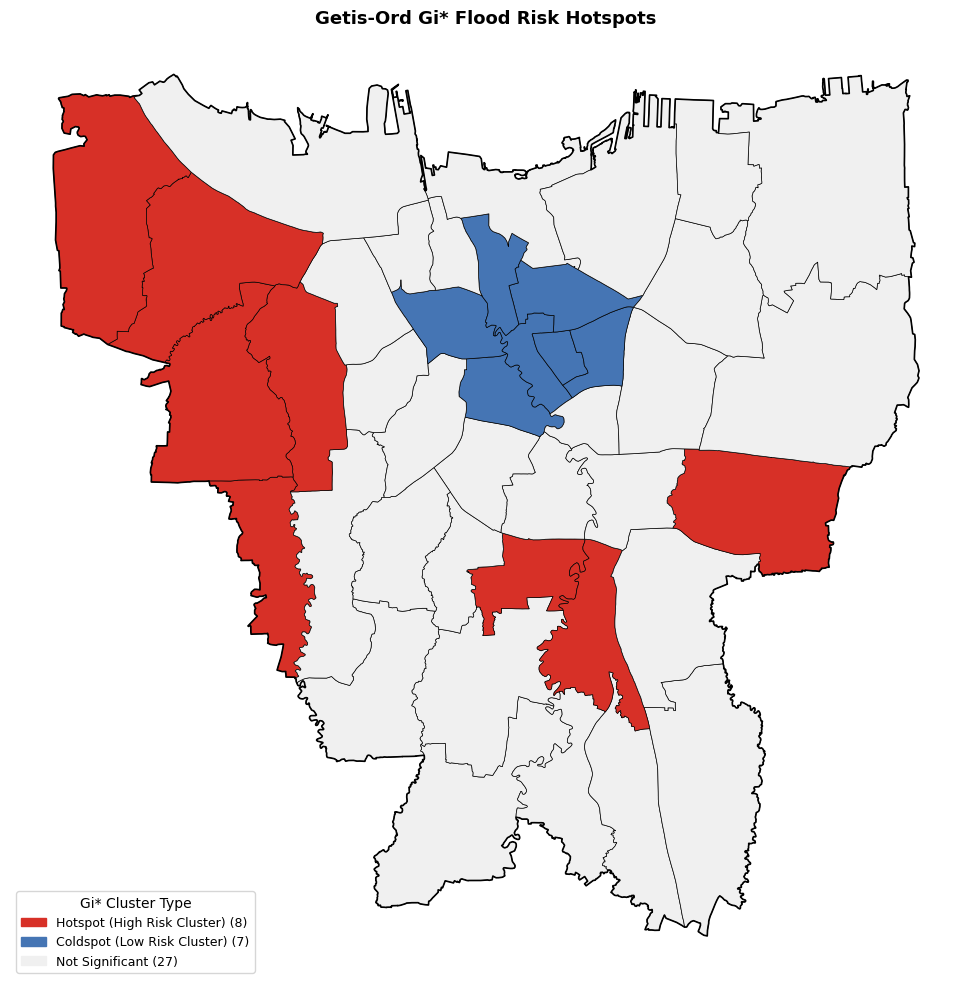

In [35]:
# Step 11b: Getis-Ord Gi* Map 
gi_colors = {
    'Hotspot (High Risk Cluster)':  '#d73027',
    'Coldspot (Low Risk Cluster)':  '#4575b4',
    'Not Significant':              '#f0f0f0'
}
district_stats['gi_color'] = district_stats['gi_cluster'].map(gi_colors).fillna('#f0f0f0')

fig, ax = plt.subplots(figsize=(10, 10))
district_stats.plot(color=district_stats['gi_color'], ax=ax, edgecolor='black', linewidth=0.5)
jakarta_mainland.boundary.plot(ax=ax, color='black', linewidth=1.2)

gi_order = ['Hotspot (High Risk Cluster)', 'Coldspot (Low Risk Cluster)', 'Not Significant']
legend_patches = [
    mpatches.Patch(color=gi_colors[g],
                   label=f'{g} ({len(district_stats[district_stats["gi_cluster"] == g])})')
    for g in gi_order if g in district_stats['gi_cluster'].values
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9, title='Gi* Cluster Type')
ax.set_title('Getis-Ord Gi* Flood Risk Hotspots', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_GETIS, dpi=150, bbox_inches='tight')
plt.show()


### Getis-Ord Gi* Key Findings

Western High-Intensity Zone (Cengkareng–Kalideres):
Statistically significant hotspot of high flood risk values, indicating concentrated intensity rather than similarity-based clustering.

Eastern/Southeastern High-Intensity Zone (Jatinegara–Kramat Jati):
Another significant hotspot driven by consistently high incident density and exposure indicators.

Central Low-Intensity Zone:
A statistically significant coldspot reflecting consistently low flood intensity across neighboring districts.

Spatial contrast:
Unlike LISA, Gi* highlights continuous intensity zones rather than local similarity structure, which explains partial overlap.

---
## 12. Kernel Density Estimation (KDE) — Historical Flood Concentration

**KDE** is applied to the historical flood incident data to produce a continuous density surface, revealing where flood events have been most densely concentrated across the city over the 2016–2020 period. Each district's centroid is weighted by its recorded incident count before KDE is computed, giving more influence to high-incident districts.


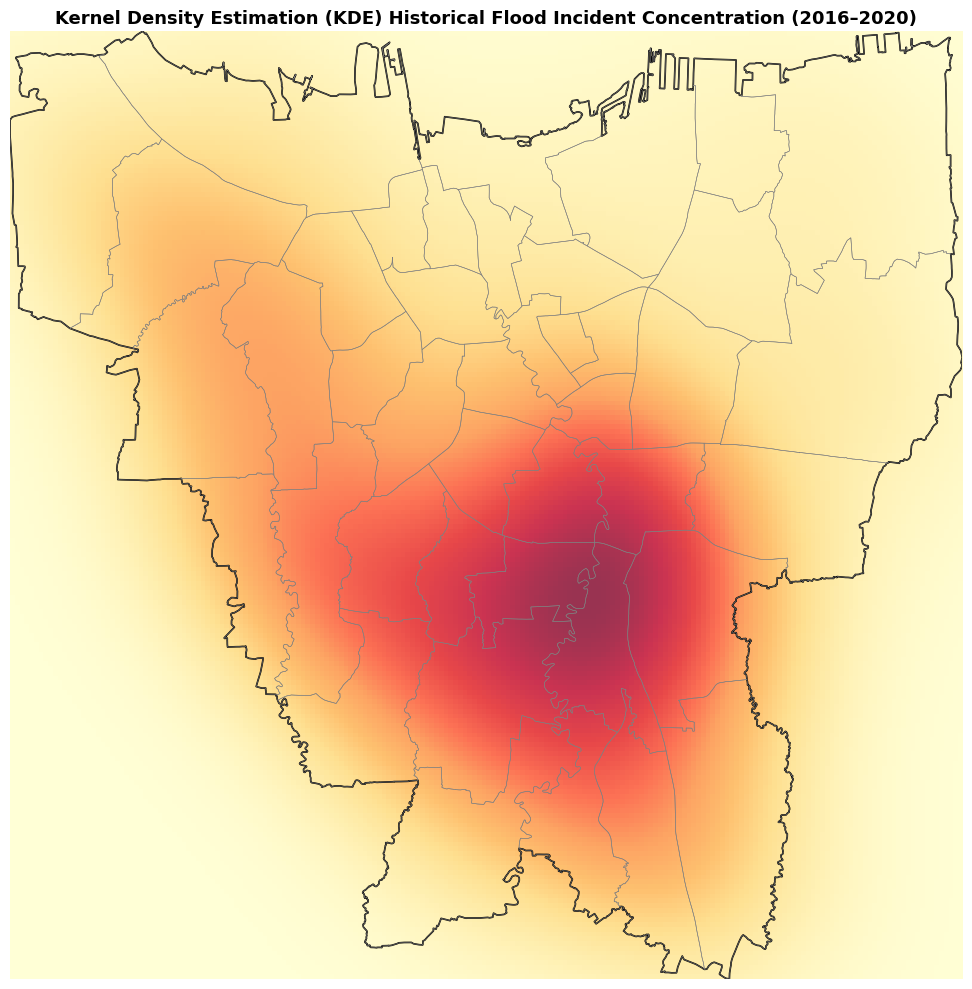

In [36]:
# Step 12: KDE of historical flood incidents
district_stats_proj = district_stats.to_crs(epsg=3857)

# Create weighted points — repeat centroid per incident count
lons, lats = [], []
for idx, row in district_stats_proj.iterrows():
    count = int(row['total_flood_incidents'])
    if count > 0:
        lons.extend([row.geometry.centroid.x] * count)
        lats.extend([row.geometry.centroid.y] * count)

lons = np.array(lons)
lats = np.array(lats)

# Fit KDE and evaluate on a 200×200 grid
kde = gaussian_kde(np.vstack([lons, lats]), bw_method=0.5)
x_min, y_min, x_max, y_max = district_stats_proj.total_bounds
xx, yy      = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
kde_values  = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
jakarta_proj = jakarta_mainland.to_crs(epsg=3857)

ax.imshow(kde_values.T, origin='lower',extent=[x_min, x_max, y_min, y_max],cmap='YlOrRd', alpha=0.8)

jakarta_proj.boundary.plot(ax=ax, color='black', linewidth=1.2)
district_stats_proj.boundary.plot(ax=ax, color='grey', linewidth=0.4)

ax.set_title('Kernel Density Estimation (KDE) Historical Flood Incident Concentration (2016–2020)',fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_KDE, dpi=150, bbox_inches='tight')
plt.show()


### KDE Results

The density surface confirms the spatial pattern identified by the Gi* analysis: the highest concentration of historical flood events is located in North and East Jakarta. The KDE provides a visually intuitive complement to the polygon-based cluster maps, illustrating the *intensity* of flood occurrence as a smooth continuous surface rather than discrete administrative units. This motivates the investigation of Jakarta's drainage infrastructure in the next section.


---
## 13. Drainage Infrastructure Analysis

One of the primary structural drivers of Jakarta's flood persistence is the **inadequacy of its drainage network** relative to the risk load. This section calculates drainage density (drainage features per km²) for each kecamatan and identifies priority zones where drainage investment is most urgently needed: districts classified as High or Very High risk that also have low drainage coverage.


=== DRAINAGE DENSITY STATISTICS ===
Mean drainage density   : 0.91
Median drainage density : 0.64
25th percentile         : 0.36


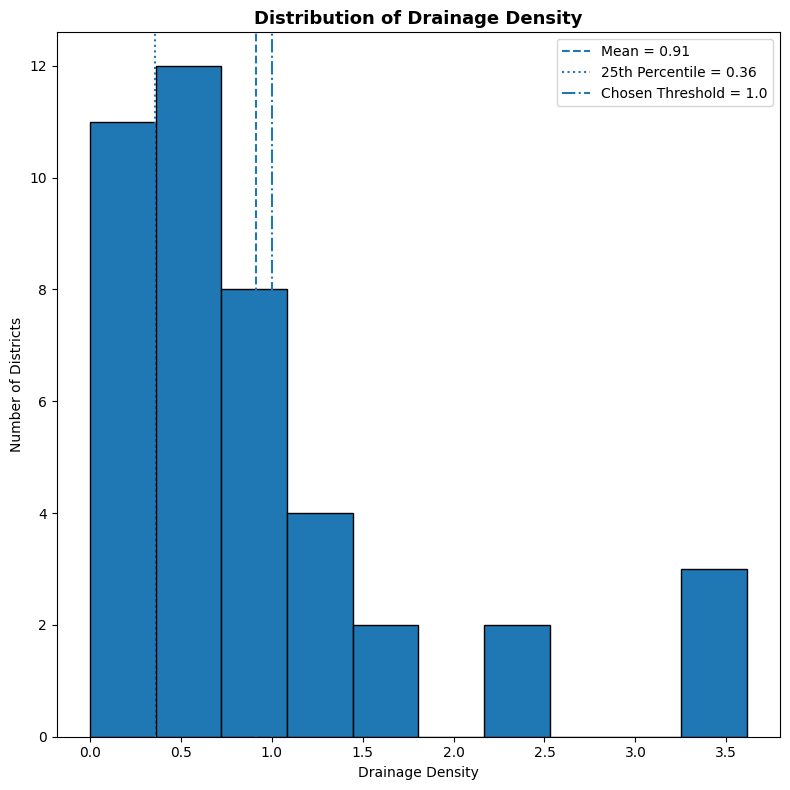

In [37]:
# Step: Explore Drainage Density Distribution

import matplotlib.pyplot as plt

# Basic statistics
mean_dd = district_stats['drainage_density'].mean()
median_dd = district_stats['drainage_density'].median()
q25 = district_stats['drainage_density'].quantile(0.25)

print('=== DRAINAGE DENSITY STATISTICS ===')
print(f'Mean drainage density   : {mean_dd:.2f}')
print(f'Median drainage density : {median_dd:.2f}')
print(f'25th percentile         : {q25:.2f}')

# Histogram
fig, ax = plt.subplots(figsize=(8, 8))

ax.hist(
    district_stats['drainage_density'].dropna(),
    bins=10,
    edgecolor='black'
)

# Add reference lines
ax.axvline(mean_dd, linestyle='--',
           label=f'Mean = {mean_dd:.2f}')

ax.axvline(q25, linestyle=':',
           label=f'25th Percentile = {q25:.2f}')

ax.axvline(1.0, linestyle='-.',
           label='Chosen Threshold = 1.0')

# Labels
ax.set_xlabel('Drainage Density')
ax.set_ylabel('Number of Districts')
ax.set_title('Distribution of Drainage Density',
             fontsize=13, fontweight='bold')

ax.legend()

plt.tight_layout()
plt.show()

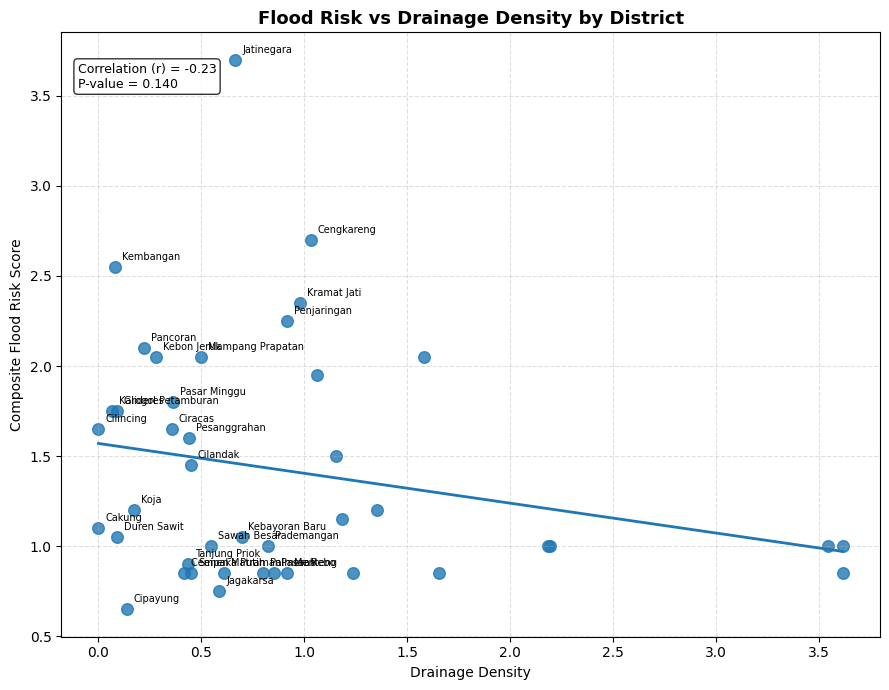

In [38]:
# Step: Scatter Plot — Flood Risk vs Drainage Density

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Remove NaN values
plot_df = district_stats[
    ['name', 'composite_score', 'drainage_density']
].dropna()

x = plot_df['drainage_density'].values
y = plot_df['composite_score'].values

# Linear regression for trendline
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Generate regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(x, y, s=70, alpha=0.8)

# Regression line
ax.plot(x_line, y_line, linewidth=2,
        label=f'Trendline (R² = {r_value**2:.2f})')

# Label important/extreme districts
for idx, row in plot_df.iterrows():
    if (row['composite_score'] >= 2.7 or
        row['drainage_density'] <= 1.0):
        
        ax.annotate(
            row['name'],
            (row['drainage_density'], row['composite_score']),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=7
        )

# Styling
ax.set_xlabel('Drainage Density')
ax.set_ylabel('Composite Flood Risk Score')
ax.set_title('Flood Risk vs Drainage Density by District',
             fontsize=13, fontweight='bold')

ax.grid(True, linestyle='--', alpha=0.4)

# Optional interpretation text
ax.text(
    0.02, 0.95,
    f'Correlation (r) = {r_value:.2f}\nP-value = {p_value:.3f}',
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

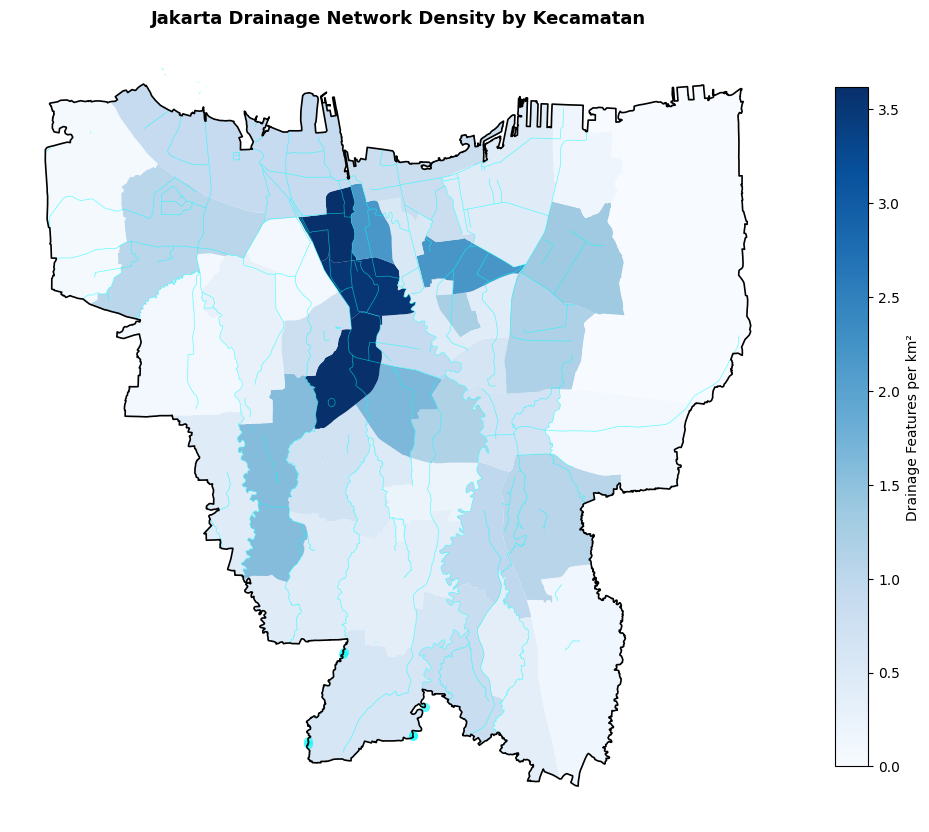

In [39]:
# Step 13b: Drainage Network Density Map
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

district_stats.plot(
    column='drainage_density',
    ax=ax, cmap='Blues', legend=True,
    legend_kwds={'label': 'Drainage Features per km²', 'shrink': 0.7}
)
drainage_gdf.plot(ax=ax, color='cyan', linewidth=0.5, alpha=0.6)
jakarta_mainland.boundary.plot(ax=ax, color='black', linewidth=1.2)

ax.set_title('Jakarta Drainage Network Density by Kecamatan', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


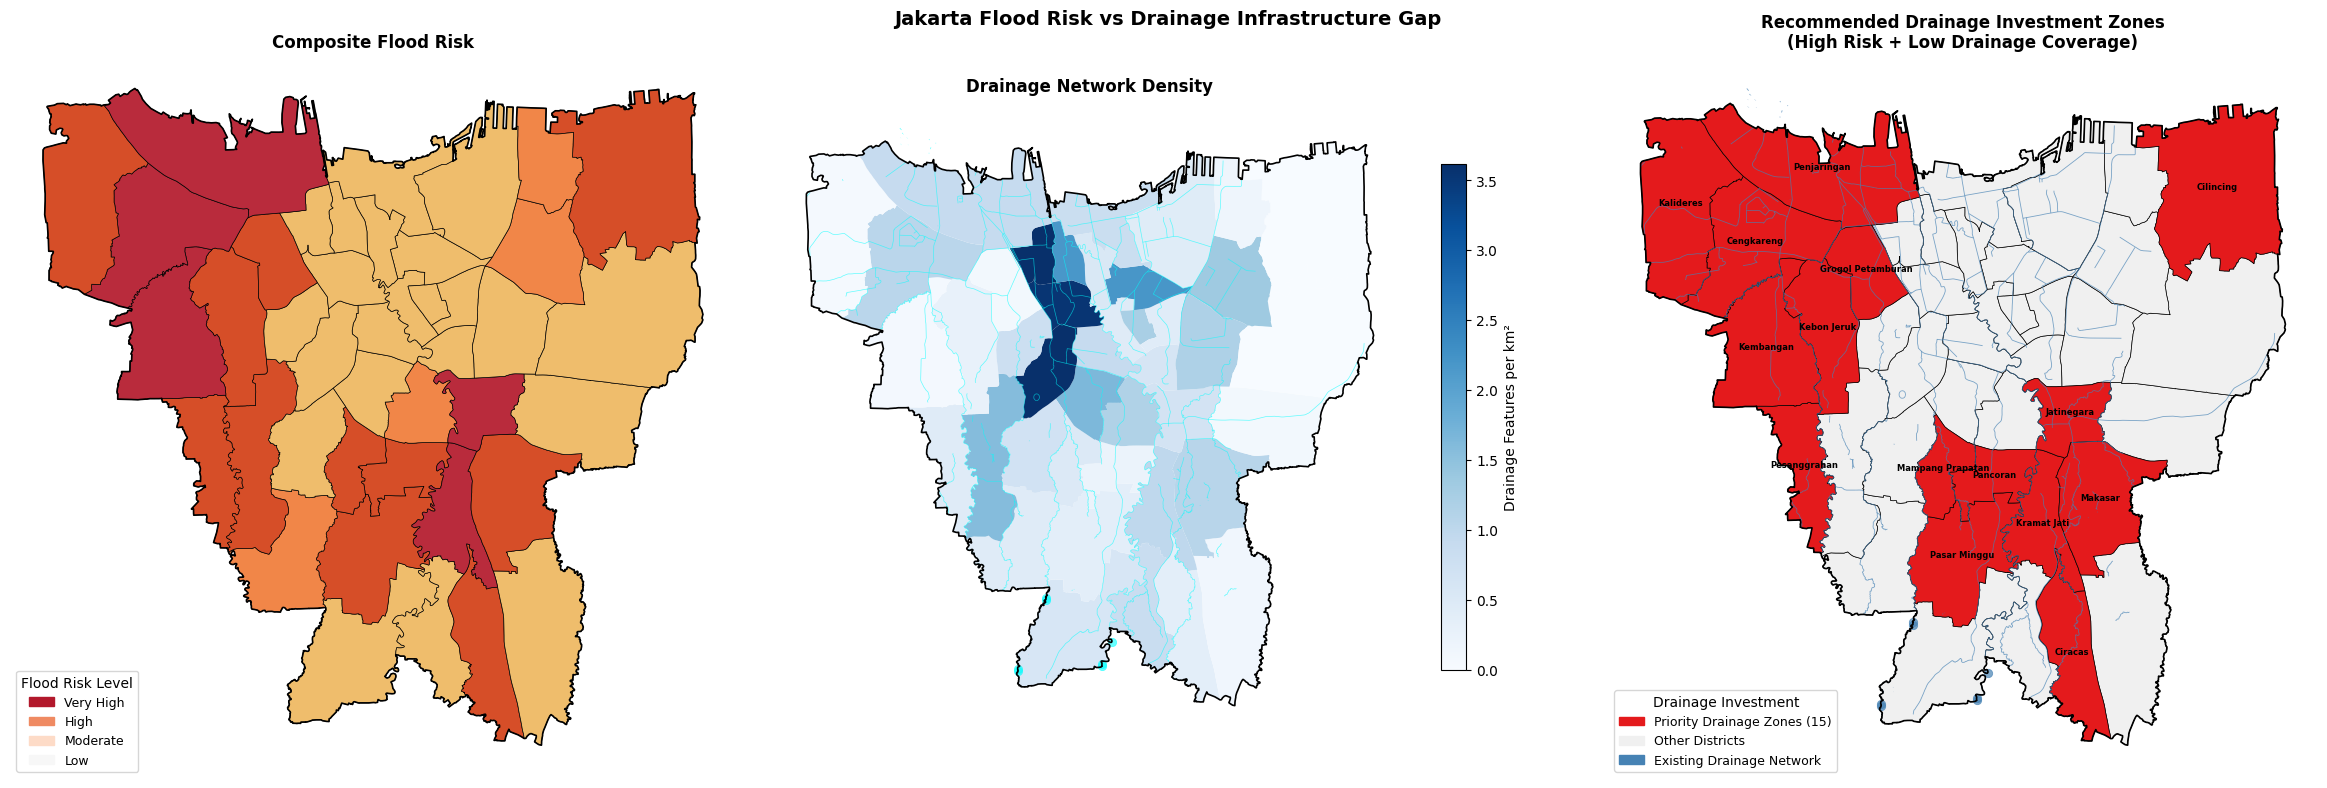

Priority drainage investment districts (15):
                 name risk_level  drainage_density  total_flood_incidents
40          Cilincing       High          0.000000                   24.0
36          Kalideres       High          0.066143                   32.0
26          Kembangan  Very High          0.078392                   54.0
29  Grogol Petamburan       High          0.091570                   25.0
3            Pancoran       High          0.221912                   63.0
25        Kebon Jeruk       High          0.279421                   67.0
10            Ciracas       High          0.356073                   80.0
2        Pasar Minggu       High          0.362797                   95.0
21       Pesanggrahan       High          0.439631                   56.0
4    Mampang Prapatan       High          0.498498                   44.0
15         Jatinegara  Very High          0.664856                  139.0
37        Penjaringan  Very High          0.913759                 

In [40]:
#  Step 13c: risk vs drainage gap
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# --- Left: Composite Risk Map ---
district_stats.plot(color=district_stats['color'], ax=axes[0], edgecolor='black', linewidth=0.5)
jakarta_mainland.boundary.plot(ax=axes[0], color='black', linewidth=1.2)
risk_colors_map = {'Very High': '#b2182b', 'High': '#ef8a62', 'Moderate': '#fddbc7', 'Low': '#f7f7f7'}
legend_patches = [mpatches.Patch(color=risk_colors_map[r], label=r)
                  for r in ['Very High', 'High', 'Moderate', 'Low']]
axes[0].legend(handles=legend_patches, loc='lower left', fontsize=9, title='Flood Risk Level')
axes[0].set_title('Composite Flood Risk', fontsize=12, fontweight='bold')
axes[0].axis('off')

# --- Middle: Drainage Density Map ---
district_stats.plot(
    column='drainage_density',
    ax=axes[1], cmap='Blues', legend=True,
    legend_kwds={'label': 'Drainage Features per km²', 'shrink': 0.7}
)
drainage_gdf.plot(ax=axes[1], color='cyan', linewidth=0.5, alpha=0.6)
jakarta_mainland.boundary.plot(ax=axes[1], color='black', linewidth=1.2)
axes[1].set_title('Drainage Network Density', fontsize=12, fontweight='bold')
axes[1].axis('off')

# --- Right: Priority Drainage Investment Zones ---
priority = district_stats[
    (district_stats['risk_level'].isin(['Very High', 'High'])) &
    (district_stats['drainage_density'] < 1.5)
].copy()
normal = district_stats[~district_stats.index.isin(priority.index)].copy()

normal.plot(ax=axes[2], color='#f0f0f0', edgecolor='black', linewidth=0.5)
priority.plot(ax=axes[2], color='#e41a1c', edgecolor='black', linewidth=0.5)
drainage_gdf.plot(ax=axes[2], color='steelblue', linewidth=0.6, alpha=0.7)
jakarta_mainland.boundary.plot(ax=axes[2], color='black', linewidth=1.2)

for idx, row in priority.iterrows():
    centroid = row.geometry.centroid
    axes[2].annotate(row['name'], xy=(centroid.x, centroid.y),
                     fontsize=6, ha='center', color='black', fontweight='bold')

legend_patches2 = [
    mpatches.Patch(color='#e41a1c', label=f'Priority Drainage Zones ({len(priority)})'),
    mpatches.Patch(color='#f0f0f0', label='Other Districts'),
    mpatches.Patch(color='steelblue', label='Existing Drainage Network')
]
axes[2].legend(handles=legend_patches2, loc='lower left', fontsize=9, title='Drainage Investment')
axes[2].set_title('Recommended Drainage Investment Zones\n(High Risk + Low Drainage Coverage)',
                  fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.suptitle('Jakarta Flood Risk vs Drainage Infrastructure Gap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DRAINAGE, dpi=150, bbox_inches='tight')
plt.show()

print(f'Priority drainage investment districts ({len(priority)}):')
print(priority[['name', 'risk_level', 'drainage_density', 'total_flood_incidents']]
      .sort_values('drainage_density').to_string())

### Drainage Analysis Results

The drainage density map reveals a structural mismatch: several of the highest-risk kecamatan in North and East Jakarta also have the lowest drainage network coverage per unit area. The priority investment map highlights districts where this double vulnerability — high flood risk combined with insufficient drainage infrastructure — creates the most acute need for engineering intervention. These findings directly inform the capital expenditure recommendations in the project's conclusion.


---
## 14. Bivariate LISA — Flood Risk vs. Population Exposure

**Bivariate Local Moran's I** tests whether high flood risk co-occurs spatially with high population density. This is critical for prioritising humanitarian response: a high-risk district with a large population represents a far greater potential human impact than an equally high-risk but sparsely populated one. The bivariate LISA identifies where these two pressures are spatially co-located.


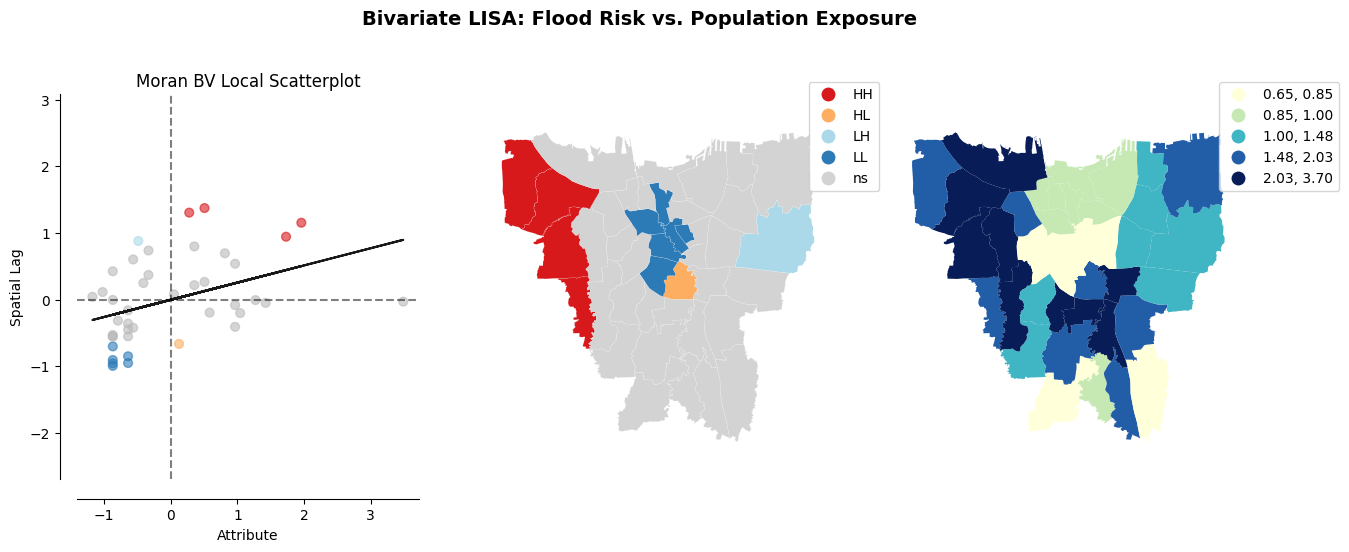

In [41]:
# Step 14: Bivariate LISA — Risk × Population 
x_val = district_stats['composite_score'].values
y_val = district_stats['population'].values

moran_bv = Moran_Local_BV(x_val, y_val, w)

fig, axs = plot_local_autocorrelation(moran_bv, district_stats, 'composite_score', figsize=(15, 5))
fig.suptitle('Bivariate LISA: Flood Risk vs. Population Exposure',
             fontsize=14, fontweight='bold', y=1.05)
plt.show()


### Bivariate LISA Results

The Bivariate LISA results show a weak positive spatial relationship between flood risk and surrounding population exposure. High–High clusters in West and Southwest Jakarta indicate areas where high-risk districts are surrounded by densely populated neighbours, increasing overall exposure. A Low–Low cluster in central Jakarta reflects consistently low risk and low surrounding population density.

Two spatial outliers are also observed: a High–Low cluster in central Jakarta, where high-risk areas are surrounded by lower population neighbours, and a Low–High cluster in eastern Jakarta, where low-risk districts are surrounded by high population density. These outliers highlight mismatches between hazard and exposure.

Overall, the weak spatial association suggests that flood risk and population are only partially aligned across Jakarta.

---
## 15. Emergency Shelter Placement Recommendation

Using the Queen spatial weights matrix, candidate shelter locations are identified as districts that satisfy three simultaneous criteria:
1. They **border** at least one High or Very High risk district (ensuring accessibility during an emergency).
2. They are **themselves classified as Moderate or Low risk** (ensuring structural safety for a shelter facility).
3. They have **mean elevation above 10 m** (providing a physical buffer against inundation).

The nearest-point algorithm then identifies the optimal shelter access point within each candidate district — the location on the district's boundary that is closest to the high-risk zone boundary.


In [42]:
# Step 15a: Identify Shelter Candidate Districts 
high_risk = district_stats[district_stats['risk_level'].isin(['Very High', 'High'])].index.tolist()

shelter_candidates = set()
for idx in high_risk:
    for n in w.neighbors[idx]:
        if (district_stats.loc[n, 'risk_level'] in ['Moderate', 'Low'] and
                district_stats.loc[n, 'mean_elevation'] > 10):
            shelter_candidates.add(n)

shelter_candidates -= set(high_risk)
shelter_df = district_stats.loc[list(shelter_candidates)].copy()

print('=== RECOMMENDED SHELTER LOCATIONS ===')
print(f'Total candidates: {len(shelter_df)}')
print(shelter_df[['name', 'risk_level', 'mean_elevation', 'population']].sort_values('population', ascending=False).to_string())


=== RECOMMENDED SHELTER LOCATIONS ===
Total candidates: 12
              name risk_level  mean_elevation     population
14     Duren Sawit        Low       17.100311  507183.591646
11        Cipayung        Low       48.669900  372935.978304
0        Jagakarsa        Low       56.660035  360725.884296
17     Pulo Gadung        Low       10.475214  331773.639878
20        Cilandak   Moderate       38.522964  273628.290399
1       Pasar Rebo        Low       48.904050  226060.716042
23  Kebayoran Baru        Low       22.422196  201403.516968
27        Palmerah        Low       10.726481  191311.148746
5            Tebet   Moderate       18.148595  181614.231306
24     Tanah Abang        Low       12.381907  180584.873502
16        Matraman        Low       12.833916  136377.668957
6        Setiabudi        Low       16.019414  120895.890091


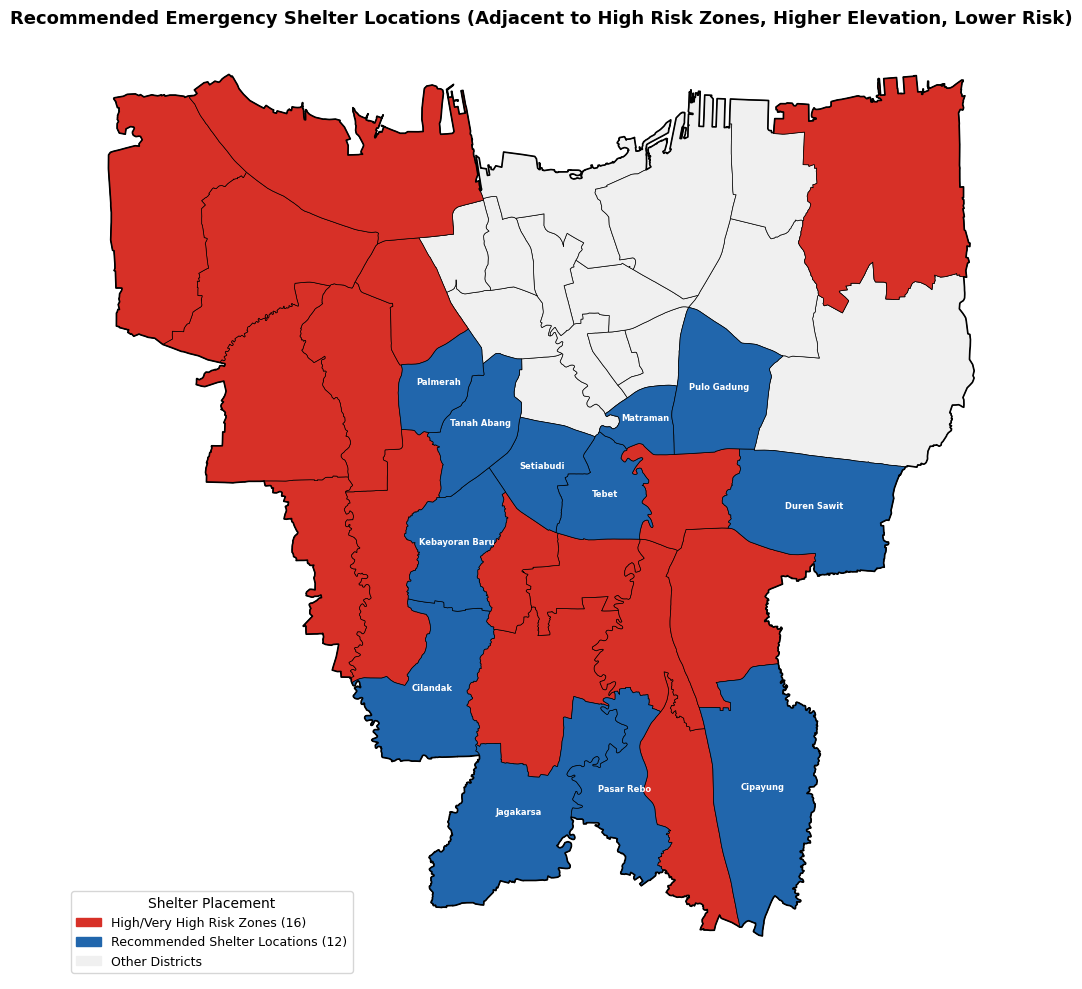

In [43]:
# Step 15b: Shelter District Map 
fig, ax = plt.subplots(figsize=(10, 10))

district_stats.plot(color='#f0f0f0', ax=ax, edgecolor='black', linewidth=0.5)
district_stats[district_stats['risk_level'].isin(['Very High', 'High'])].plot(
    color='#d73027', ax=ax, edgecolor='black', linewidth=0.5)
shelter_df.plot(color='#2166ac', ax=ax, edgecolor='black', linewidth=0.5)

for idx, row in shelter_df.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                fontsize=6, ha='center', fontweight='bold', color='white')

jakarta_mainland.boundary.plot(ax=ax, color='black', linewidth=1.2)

n_high = len(district_stats[district_stats['risk_level'].isin(['Very High', 'High'])])
legend_patches = [
    mpatches.Patch(color='#d73027', label=f'High/Very High Risk Zones ({n_high})'),
    mpatches.Patch(color='#2166ac', label=f'Recommended Shelter Locations ({len(shelter_df)})'),
    mpatches.Patch(color='#f0f0f0', label='Other Districts')
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9, title='Shelter Placement')
ax.set_title('Recommended Emergency Shelter Locations (Adjacent to High Risk Zones, Higher Elevation, Lower Risk)',fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_SHELTER, dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_11800\3471314187.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ].geometry.unary_union


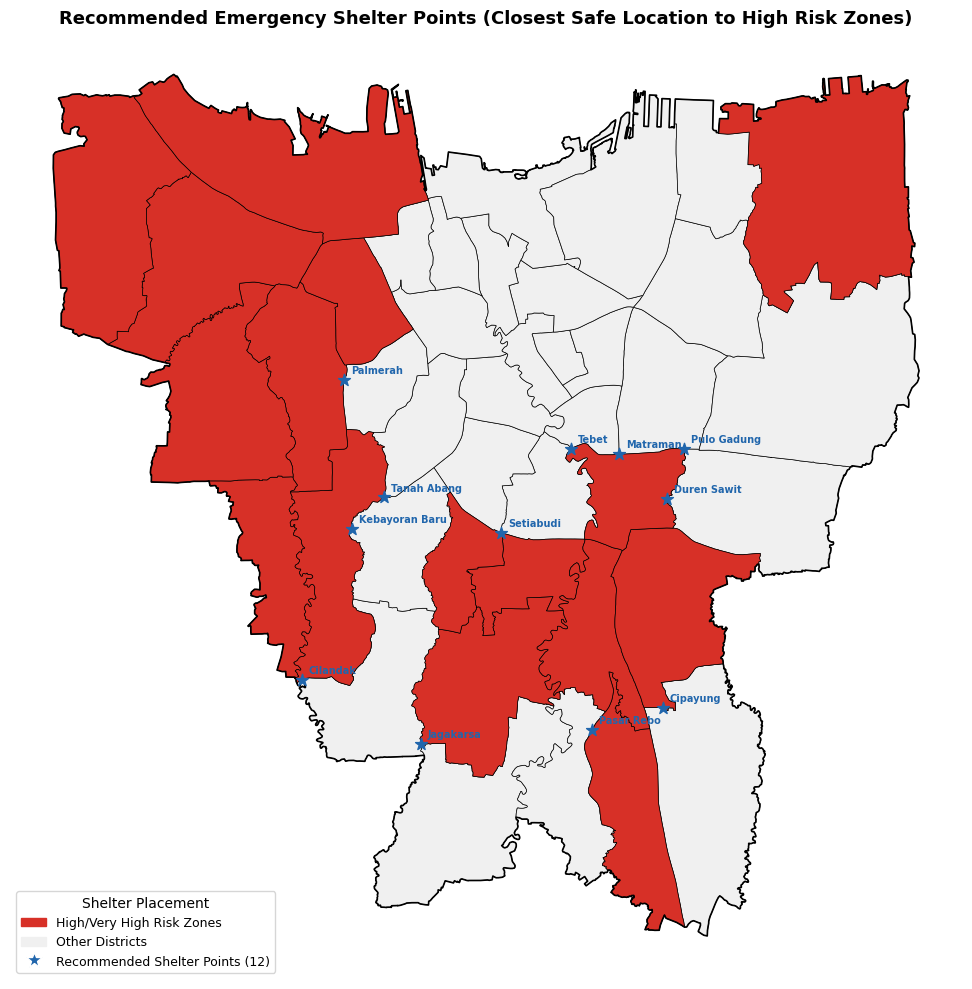

In [44]:
# Step 15c: optimal shelter access points (nearest to risk boundary) 
high_risk_geom = district_stats[
    district_stats['risk_level'].isin(['Very High', 'High'])
].geometry.unary_union

shelter_points = []
for idx, row in shelter_df.iterrows():
    p1, p2 = nearest_points(row.geometry, high_risk_geom)
    shelter_points.append({
        'name':       row['name'],
        'geometry':   p1,
        'population': row['population'],
        'elevation':  row['mean_elevation']
    })

shelter_points_gdf = gpd.GeoDataFrame(shelter_points, crs=district_stats.crs)

fig, ax = plt.subplots(figsize=(10, 10))
district_stats.plot(color='#f0f0f0', ax=ax, edgecolor='black', linewidth=0.5)
district_stats[district_stats['risk_level'].isin(['Very High', 'High'])].plot(
    color='#d73027', ax=ax, edgecolor='black', linewidth=0.5)
shelter_points_gdf.plot(ax=ax, color='#2166ac', markersize=80, marker='*', zorder=5)

for idx, row in shelter_points_gdf.iterrows():
    ax.annotate(row['name'], xy=(row.geometry.x, row.geometry.y),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7, fontweight='bold', color='#2166ac')

jakarta_mainland.boundary.plot(ax=ax, color='black', linewidth=1.2)

legend_patches = [
    mpatches.Patch(color='#d73027', label='High/Very High Risk Zones'),
    mpatches.Patch(color='#f0f0f0', label='Other Districts'),
]
legend_points = plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='#2166ac',
                            markersize=12,
                            label=f'Recommended Shelter Points ({len(shelter_points_gdf)})')
ax.legend(handles=legend_patches + [legend_points], loc='lower left', fontsize=9,title='Shelter Placement')
ax.set_title('Recommended Emergency Shelter Points (Closest Safe Location to High Risk Zones)',fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_SHELTER_PTS, dpi=150, bbox_inches='tight')
plt.show()


### Shelter Placement Results

The spatial neighbour algorithm identifies a set of lower-risk, higher-elevation districts that are directly adjacent to the high-risk corridor. These locations satisfy all three siting criteria and represent optimal positions for permanent emergency infrastructure: close enough to be accessible during a flood event, but geographically protected from the hazard themselves.

The nearest-point map refines these recommendations further, identifying the specific access point on each shelter district's boundary that minimises the distance to the nearest high-risk zone — critical information for emergency route planning and logistics.

---

## 16. Conclusion

This analysis demonstrates that Jakarta's flood vulnerability is spatially structured, regionally continuous, and highly non-random. The convergence of six independent methods,  MCE scoring, Global Moran's I, LISA, Getis-Ord Gi*, ML Spatial Lag regression, and KDE, all point to the same geographic conclusion: flood risk is concentrated in a persistent West and Southeast hotspot pattern with additional localized clusters driven by compounding elevation, hazard, historical incident, and drainage infrastructure deficits.

The spatial regression proof shows that this risk is fundamentally a regional contagion process, not a set of independent local problems. Effective mitigation requires coordinated, cross-boundary engineering and governance responses scaled to the regional hotspot blocks identified in this analysis.


In [45]:
district_stats.to_file(os.path.join(DATA_DIR, "district_stats_final.geojson"), driver="GeoJSON")